# SDV Models: Comprehensive Evaluation - MAGIC Gamma Telescope Dataset

This notebook contains a comprehensive evaluation of four synthetic data generation models on the **MAGIC Gamma Telescope** dataset (UCI id=159):
1. **CopulaGAN** - GAN-based with copula modeling
2. **Gaussian Copula** - Statistical copula-based approach
3. **CTGAN** - Conditional Tabular GAN
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## 1. Data Loading and Setup


In [1]:
import pandas as pd
from sdv.metadata import SingleTableMetadata
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo

# fetch dataset
magic_gamma_telescope = fetch_ucirepo(id=159)

# data (as pandas dataframes)
X = magic_gamma_telescope.data.features
y = magic_gamma_telescope.data.targets

# metadata
print(magic_gamma_telescope.metadata)

# variable information
print(magic_gamma_telescope.variables)

# Combine features and target for SDV
magic_data = pd.concat([X, y], axis=1)

# Encode class: g (gamma) -> 1, h (hadron) -> 0
magic_data['class'] = magic_data['class'].replace({'g': 1, 'h': 0})

# Handle missing values
magic_data = magic_data.fillna(magic_data.mean(numeric_only=True))
for col in magic_data.columns:
    if magic_data[col].isnull().any():
        magic_data[col] = magic_data[col].fillna(magic_data[col].mode()[0])

print("Data cleaned successfully!")
print(magic_data.head())

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(magic_data)
print(f"Metadata detected. Columns found: {len(magic_data.columns)}")

# Subsample for O(n^2) pairwise metrics (~19k rows -> full kernel matrices need tens of GB).
METRIC_SAMPLE_SIZE = 2000
METRIC_RANDOM_STATE = 42

def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
    if len(df) <= n_max:
        return df.reset_index(drop=True)
    return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)


{'uci_id': 159, 'name': 'MAGIC Gamma Telescope', 'repository_url': 'https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope', 'data_url': 'https://archive.ics.uci.edu/static/public/159/data.csv', 'abstract': 'Data are MC generated to simulate registration of high energy gamma particles in an atmospheric Cherenkov telescope', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 19020, 'num_features': 10, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2004, 'last_updated': 'Tue Dec 19 2023', 'dataset_doi': '10.24432/C52C8B', 'creators': ['R. Bock'], 'intro_paper': None, 'additional_info': {'summary': "The data are MC generated (see below) to simulate registration of high energy gamma particles in a ground-based atmospheric Cherenkov gamma telescope using the imaging technique. Cherenkov gamm

# 2. Generating Synthetic data for Four SDV Models


In [2]:
from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic
import pandas as pd

# Use the dataset you loaded in this notebook
real_data = magic_data.copy()

# Number of synthetic rows to generate per model
n_samples = 1000

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(real_data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data=real_data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

# Memory-safe subsampling for pairwise metrics (MAGIC ~19k rows).
METRIC_SAMPLE_SIZE = 2000
METRIC_RANDOM_STATE = 42

def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
    if len(df) <= n_max:
        return df.reset_index(drop=True)
    return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)



Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 242.26it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 282.41it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 230.18it/s]|
Column Shapes Score: 89.17%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 143.35it/s]|
Column Pair Trends Score: 89.7%

Overall Score (Average): 89.44%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 11/11 [00:00<00:00, 532.70it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 362.92it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 241.51it/s]|
Column Shapes Score: 90.39%

(2/2) Eva

,Model,Diagnostic Score,Quality Score
0,TVAE,1.0,0.928895
1,GaussianCopula,1.0,0.895806
2,CTGAN,1.0,0.894375
3,CopulaGAN,1.0,0.888847



Best model by quality score: TVAE


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,55.1122,25.1727,3.2496,0.3031,0.1282,13.8933,23.2355,12.9814,3.3439,204.2513,1
1,21.0249,16.4469,2.4402,0.5004,0.2653,-13.8016,-17.5653,8.0009,81.6845,24.0295,1
2,87.1432,19.4300,3.9313,0.2600,0.1243,-79.4583,30.0241,-32.5589,2.9359,241.8649,1
3,91.7498,42.8546,3.7006,0.2856,0.0894,21.8390,34.4367,26.3605,0.9590,238.2870,1
4,28.9972,11.1098,2.1781,0.5470,0.2880,2.9253,25.9419,-6.9984,1.6032,158.6544,1


# 1. Univariate Analysis
#### 1.1. Kolmogorov-Smirnov (K-S) test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 240.49it/s]|
Column Shapes Score: 89.17%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 134.51it/s]|
Column Pair Trends Score: 89.7%

Overall Score (Average): 89.44%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 338.36it/s]|
Column Shapes Score: 90.39%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 140.40it/s]|
Column Pair Trends Score: 87.38%

Overall Score (Average): 88.88%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 209.68it/s]|
Column Shapes Score: 92.2%

(2/2) Evaluating Column Pair Trends: |██████████| 55/55 [00:00<00:00, 128.95it/s]|
Column Pair Trends Score: 93.58%

Overall Score (Average): 92.89%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 11/11 [00:00<00:00, 197.34it/s]|
Column Shapes Score: 91.0%

(2/2) Evaluating Column Pair Tren

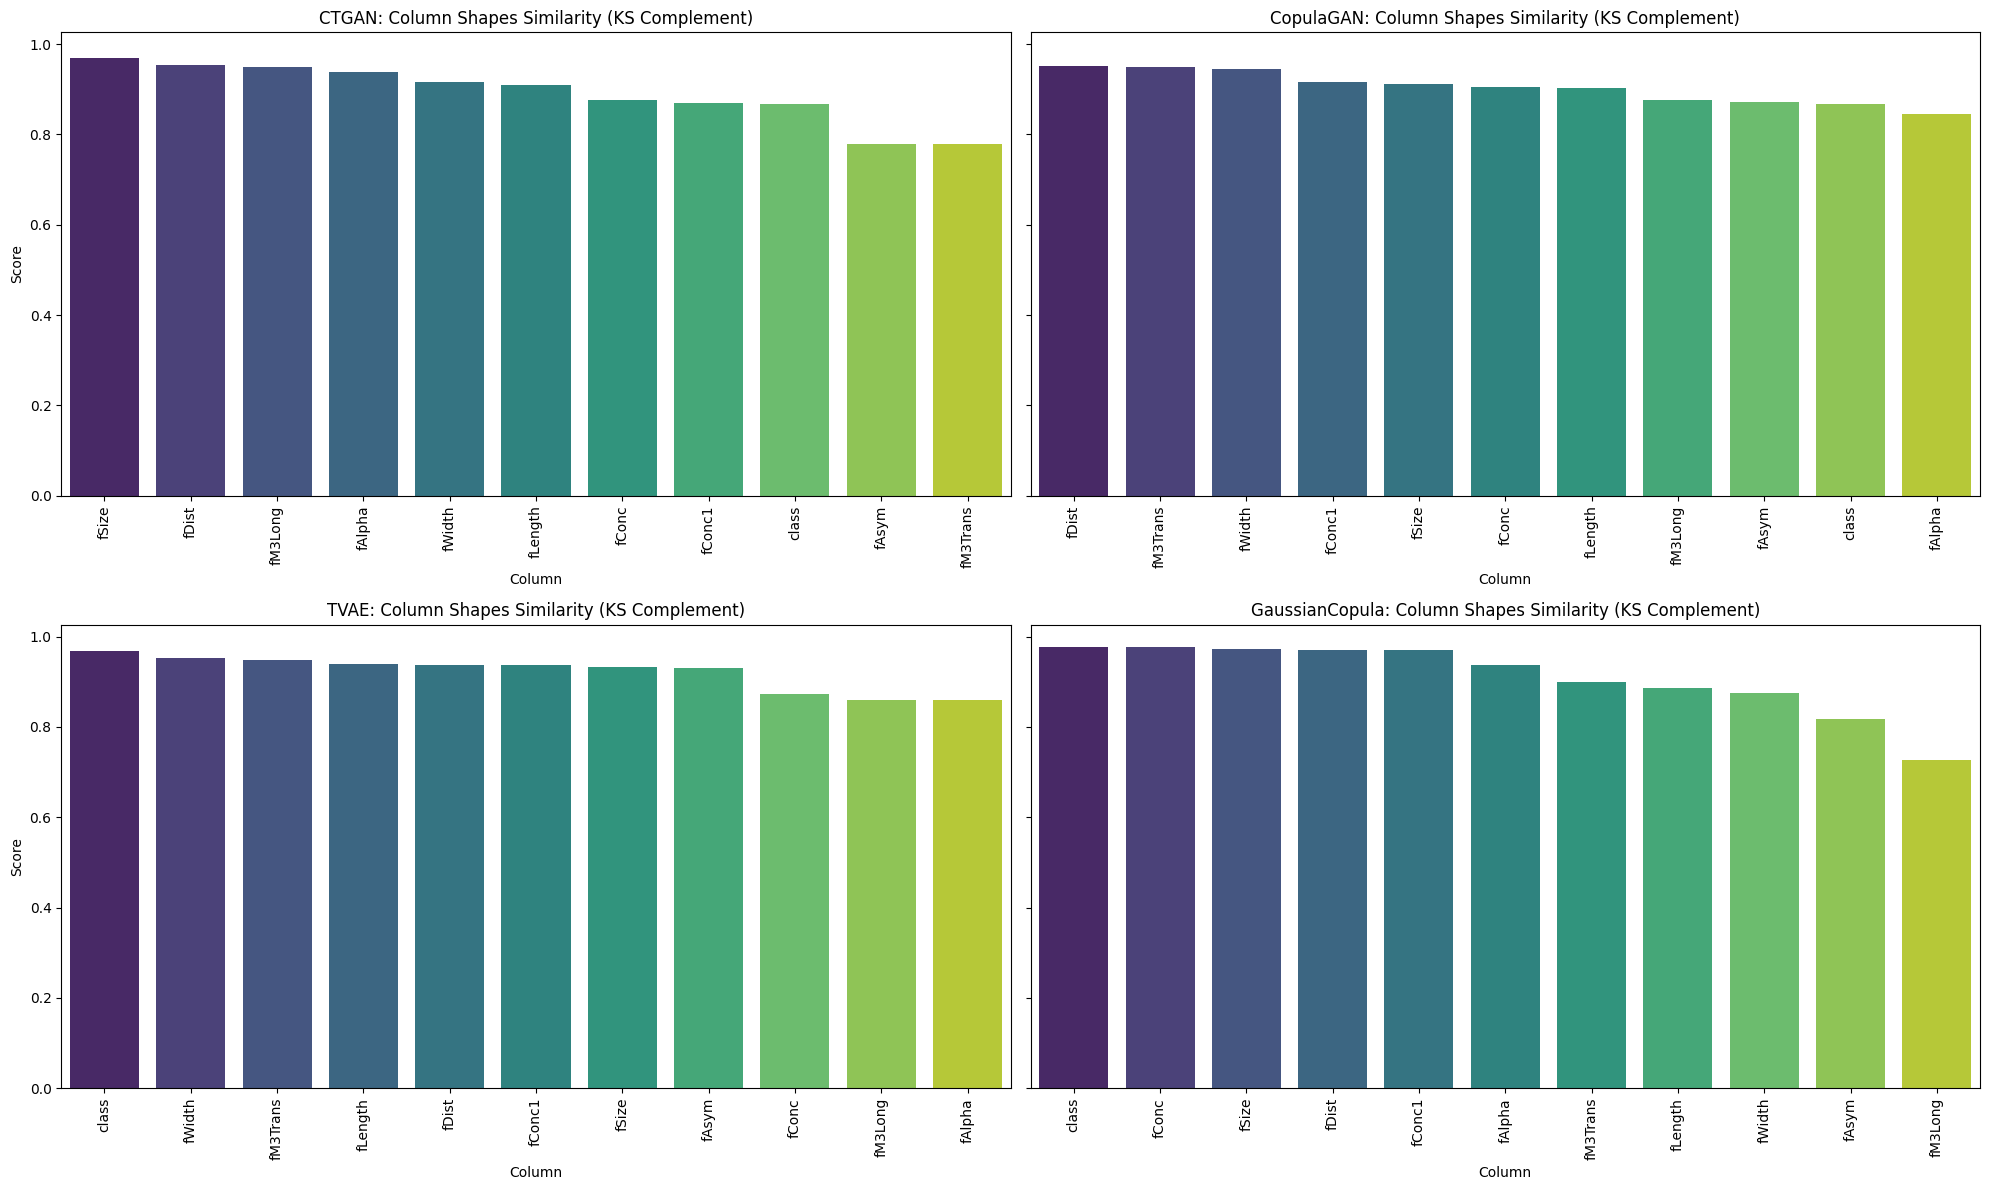

,Column,Metric,Score,Model
0,fSize,KSComplement,0.968607,CTGAN
1,fDist,KSComplement,0.953891,CTGAN
2,fM3Long,KSComplement,0.949741,CTGAN
3,fAlpha,KSComplement,0.938563,CTGAN
4,fWidth,KSComplement,0.917307,CTGAN
5,fLength,KSComplement,0.909729,CTGAN
6,fConc,KSComplement,0.875714,CTGAN
7,fConc1,KSComplement,0.869403,CTGAN
8,class,TVComplement,0.867630,CTGAN
9,fAsym,KSComplement,0.779975,CTGAN


In [3]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
column_shape_details = {}

for model_name in model_order:
    qr = QualityReport()
    qr.generate(
        real_data=real_data,
        synthetic_data=synthetic_datasets[model_name],
        metadata=metadata.to_dict()
    )
    details = qr.get_details(property_name="Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


#### 1.2. Jensen–Shannon divergence


In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()
    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)
    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame, synth_df: pd.DataFrame, bins=30, normalize=True) -> pd.DataFrame:
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        if num_cols:
            scaler = MinMaxScaler()
            real[num_cols] = scaler.fit_transform(real[num_cols])
            synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]
        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)
        js_div = jensenshannon(p, q, base=2) ** 2
        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


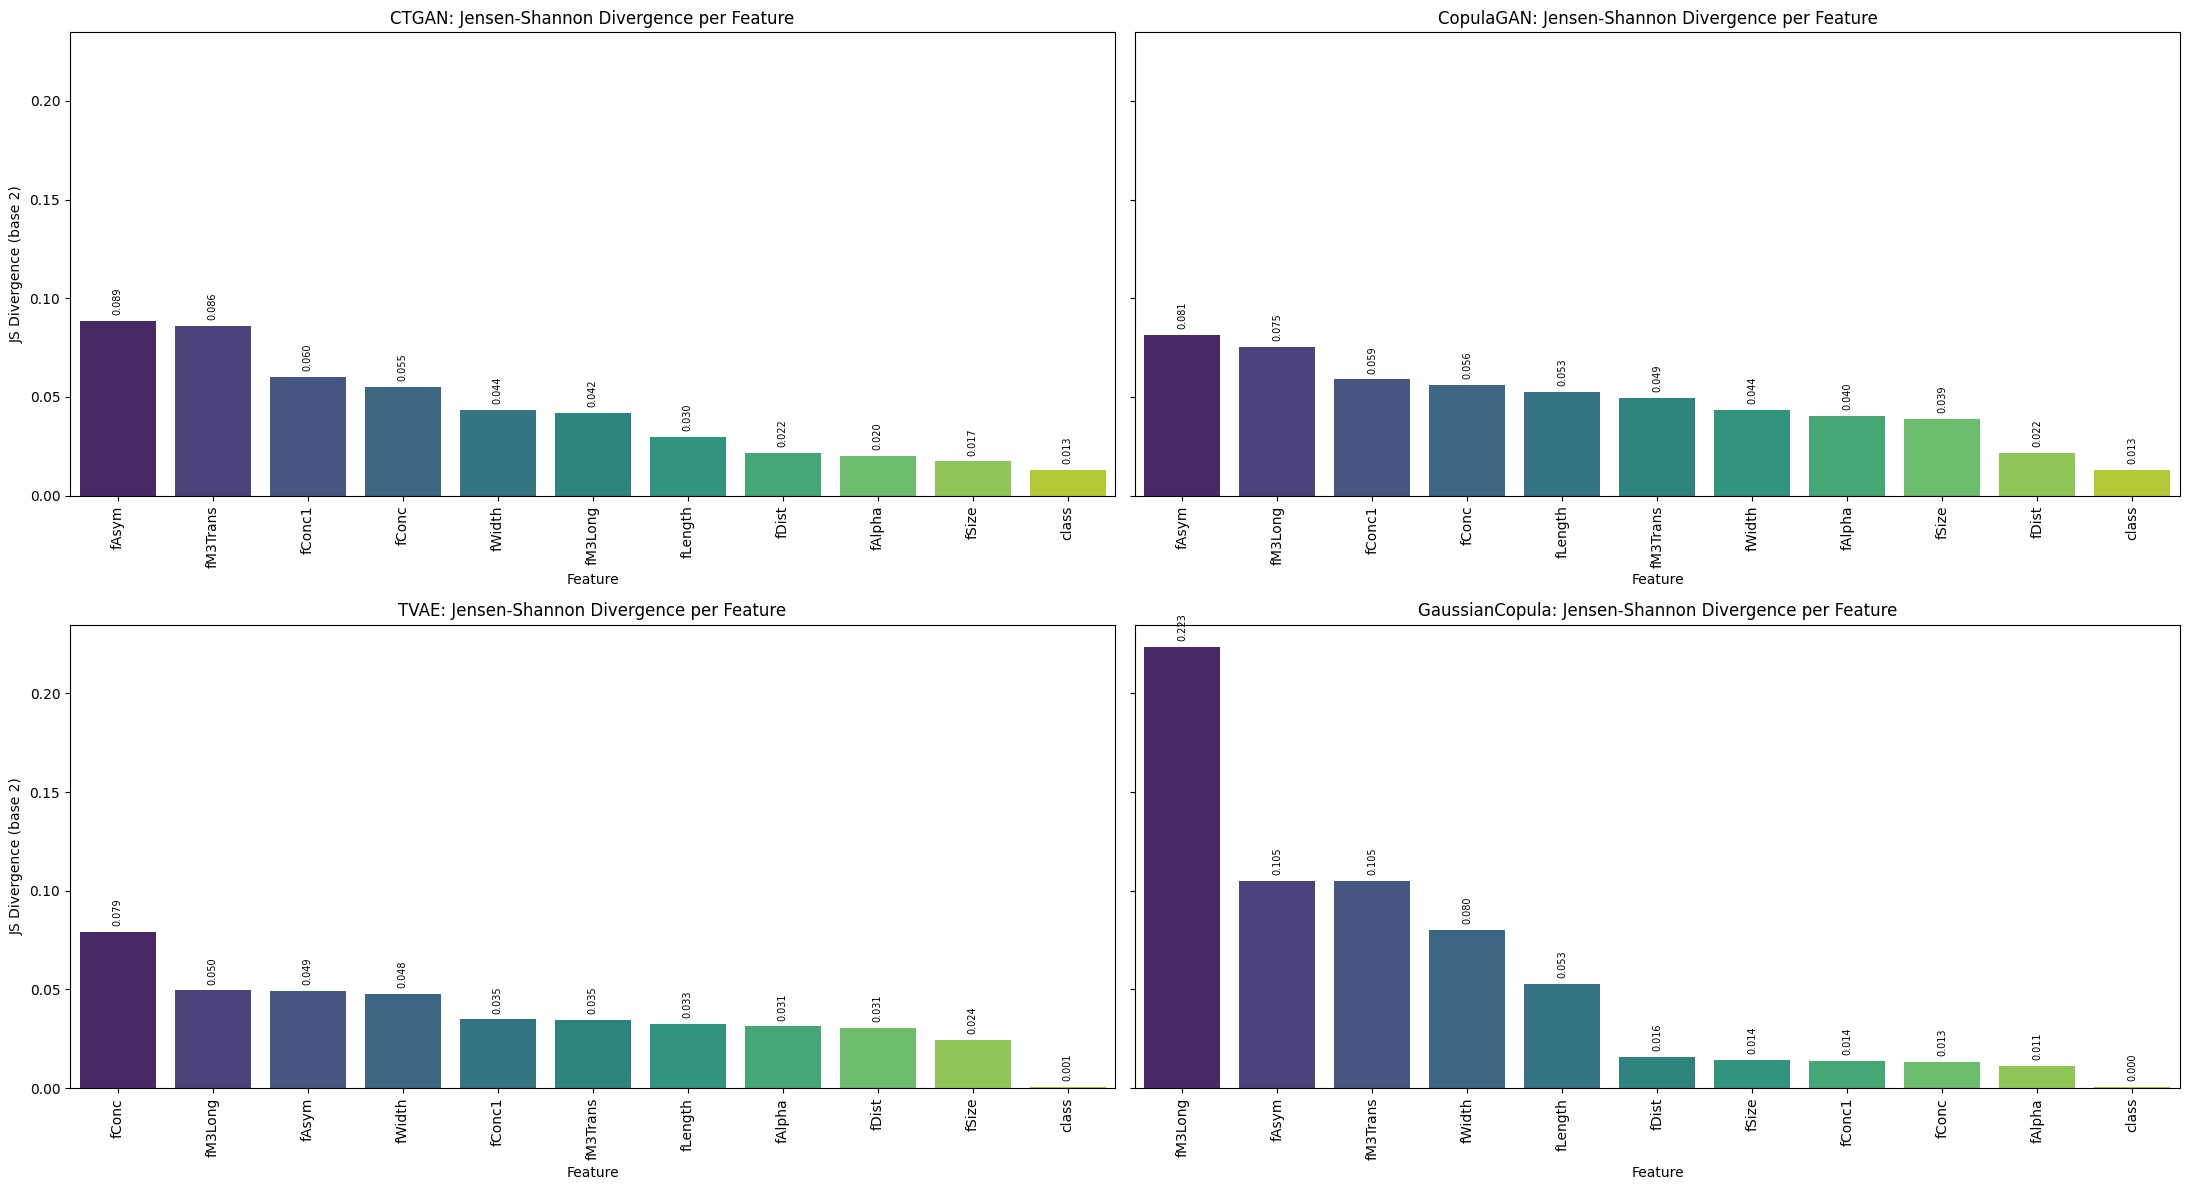

,Feature,JS_Divergence,Model
0,fAsym,0.088532,CTGAN
1,fM3Trans,0.085756,CTGAN
2,fConc1,0.059929,CTGAN
3,fConc,0.054960,CTGAN
4,fWidth,0.043654,CTGAN
5,fM3Long,0.042017,CTGAN
6,fLength,0.029549,CTGAN
7,fDist,0.021821,CTGAN
8,fAlpha,0.020178,CTGAN
9,fSize,0.017366,CTGAN


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd, numpy as np

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

for model_name in model_order:
    js_df = compute_js_divergence(
        real_data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))


#### 1.3 Wasserstein Distance


In [7]:
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

real_data = magic_data.copy()
numeric_cols = real_data.select_dtypes(include=[np.number]).columns
wasserstein_results = {}

for model_name, synth_df in synthetic_datasets.items():
    common_numeric_cols = [c for c in numeric_cols if c in synth_df.columns]
    scaler = StandardScaler().fit(real_data[common_numeric_cols])

    real_scaled = pd.DataFrame(
        scaler.transform(real_data[common_numeric_cols]),
        columns=common_numeric_cols
    )
    synth_scaled = pd.DataFrame(
        scaler.transform(synth_df[common_numeric_cols]),
        columns=common_numeric_cols
    )

    wasserstein_scores = []
    for col in common_numeric_cols:
        r = real_scaled[col].dropna().astype(float)
        s = synth_scaled[col].dropna().astype(float)

        try:
            w_dist = wasserstein_distance(r, s)
        except Exception:
            w_dist = np.nan

        wasserstein_scores.append({"Column": col, "Wasserstein": w_dist})

    results_df = pd.DataFrame(wasserstein_scores).sort_values("Wasserstein")
    wasserstein_results[model_name] = results_df

    print(f"\nWasserstein distances for {model_name}:")
    print(results_df)



Wasserstein distances for CTGAN:
      Column  Wasserstein
2      fSize     0.045705
9      fDist     0.084734
8     fAlpha     0.085016
6    fM3Long     0.105774
0    fLength     0.106027
1     fWidth     0.142109
3      fConc     0.229466
4     fConc1     0.246750
5      fAsym     0.272185
10     class     0.277227
7   fM3Trans     0.403219

Wasserstein distances for CopulaGAN:
      Column  Wasserstein
9      fDist     0.078058
2      fSize     0.102686
1     fWidth     0.111364
8     fAlpha     0.165102
3      fConc     0.167529
4     fConc1     0.212546
7   fM3Trans     0.216430
6    fM3Long     0.271563
10     class     0.277227
0    fLength     0.281636
5      fAsym     0.445618

Wasserstein distances for TVAE:
      Column  Wasserstein
10     class     0.064149
2      fSize     0.090800
1     fWidth     0.097119
7   fM3Trans     0.102462
9      fDist     0.102490
4     fConc1     0.113396
5      fAsym     0.117777
0    fLength     0.119887
8     fAlpha     0.164168
3      fCon


CTGAN - Wasserstein Distance:
fLength: 0.0136
fWidth: 0.0102
fSize: 0.0064
fConc: 0.0477
fConc1: 0.0404
fAsym: 0.0156
fM3Long: 0.0095
fM3Trans: 0.0218
fAlpha: 0.0247
fDist: 0.0128
class: 0.1324

CopulaGAN - Wasserstein Distance:
fLength: 0.0362
fWidth: 0.0080
fSize: 0.0143
fConc: 0.0348
fConc1: 0.0348
fAsym: 0.0255
fM3Long: 0.0243
fM3Trans: 0.0117
fAlpha: 0.0479
fDist: 0.0118
class: 0.1324

TVAE - Wasserstein Distance:
fLength: 0.0154
fWidth: 0.0069
fSize: 0.0127
fConc: 0.0396
fConc1: 0.0186
fAsym: 0.0067
fM3Long: 0.0180
fM3Trans: 0.0055
fAlpha: 0.0476
fDist: 0.0155
class: 0.0306

GaussianCopula - Wasserstein Distance:
fLength: 0.0152
fWidth: 0.0156
fSize: 0.0057
fConc: 0.0098
fConc1: 0.0077
fAsym: 0.0191
fM3Long: 0.0862
fM3Trans: 0.0116
fAlpha: 0.0254
fDist: 0.0065
class: 0.0226

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,TVAE,0.019745,0.015495,0.047614
1,GaussianCopula,0.020501,0.015228,0.086211
2,CTGAN,0.030447,0.015597,0.132370
3,CopulaGAN,0.034697,0.025536,0.132370


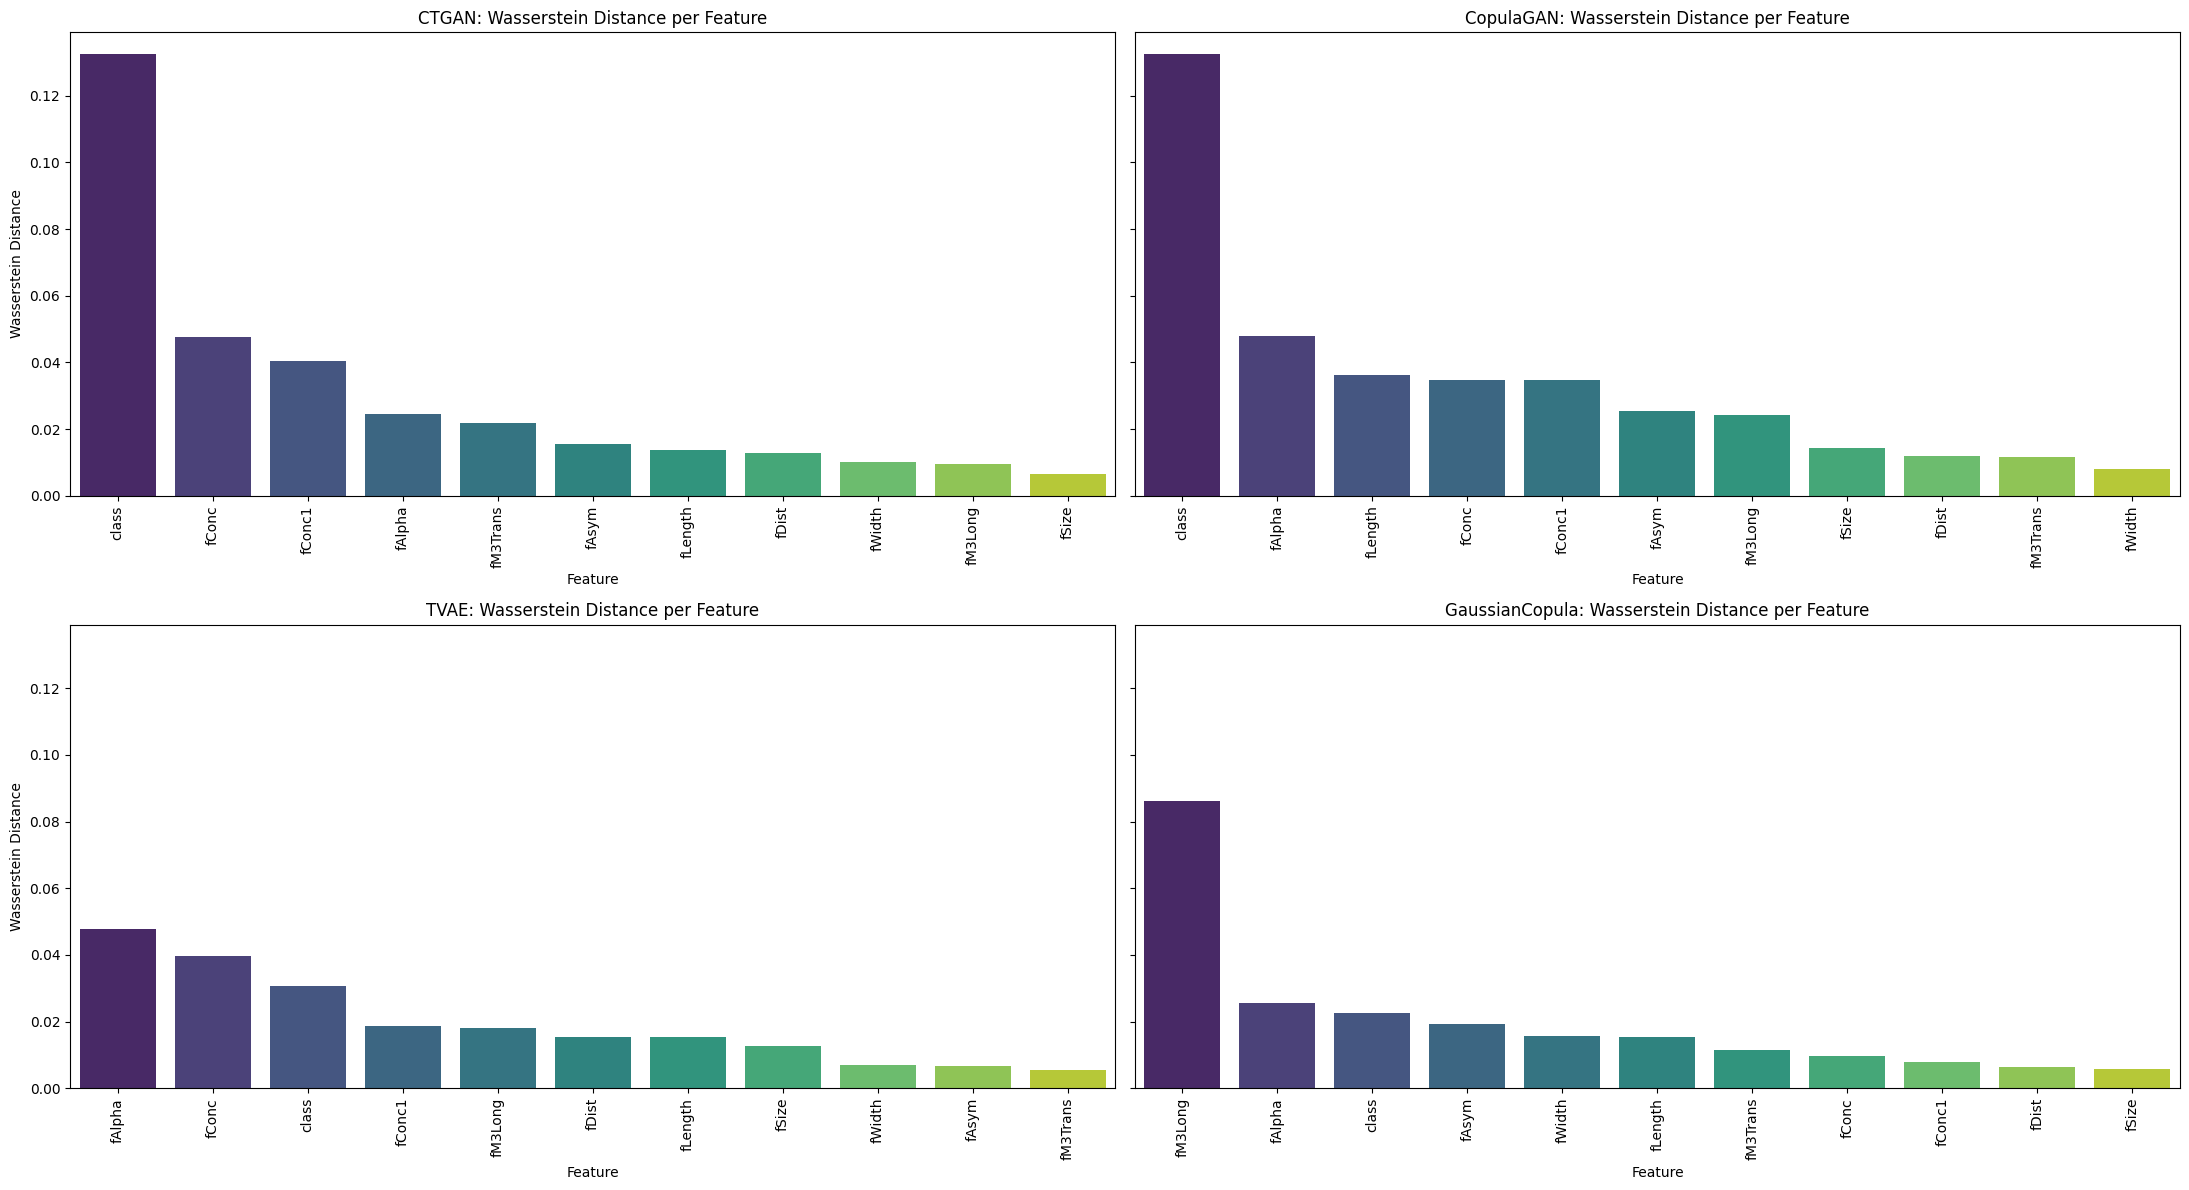

In [8]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in common_cols:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()


#### 1.4 Gower Distance 


In [9]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd
import gower

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

X_real = real_data.drop(columns=[target_col], errors="ignore")
gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore")

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = metric_subsample_df(X_real[common_cols])
    Xs = X_synth[common_cols].reset_index(drop=True)

    gower_real = 1 - gower.gower_matrix(Xr)
    gower_synth = 1 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = np.max(real_upper)
    avg_intra_real = np.mean(real_upper)
    max_intra_synth = np.max(synth_upper)
    avg_intra_synth = np.mean(synth_upper)

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = np.max(cross_block)
    avg_cross = np.mean(cross_block)

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8551

Intra-set Similarity (Synthetic):
Max = 0.9822, Avg = 0.8144

Cross-set Similarity (Real vs Synthetic):
Max = 0.9906, Avg = 0.8535

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8551

Intra-set Similarity (Synthetic):
Max = 0.9829, Avg = 0.8078

Cross-set Similarity (Real vs Synthetic):
Max = 0.9924, Avg = 0.8475

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8551

Intra-set Similarity (Synthetic):
Max = 0.9895, Avg = 0.8346

Cross-set Similarity (Real vs Synthetic):
Max = 0.9939, Avg = 0.8643

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.8551

Intra-set Similarity (Synthetic):
Max = 0.9739, Avg = 0.7971

Cross-set Similarity (Real vs Synthetic):
Max = 0.9892, Avg = 0.8467


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,1.0,0.855107,0.982157,0.814407,0.990613,0.853544
1,CopulaGAN,1.0,0.855107,0.982947,0.807789,0.992351,0.847494
2,TVAE,1.0,0.855107,0.989478,0.834551,0.993873,0.864338
3,GaussianCopula,1.0,0.855107,0.973858,0.797055,0.989238,0.846668


#### 1.5. t-SNE Visualization


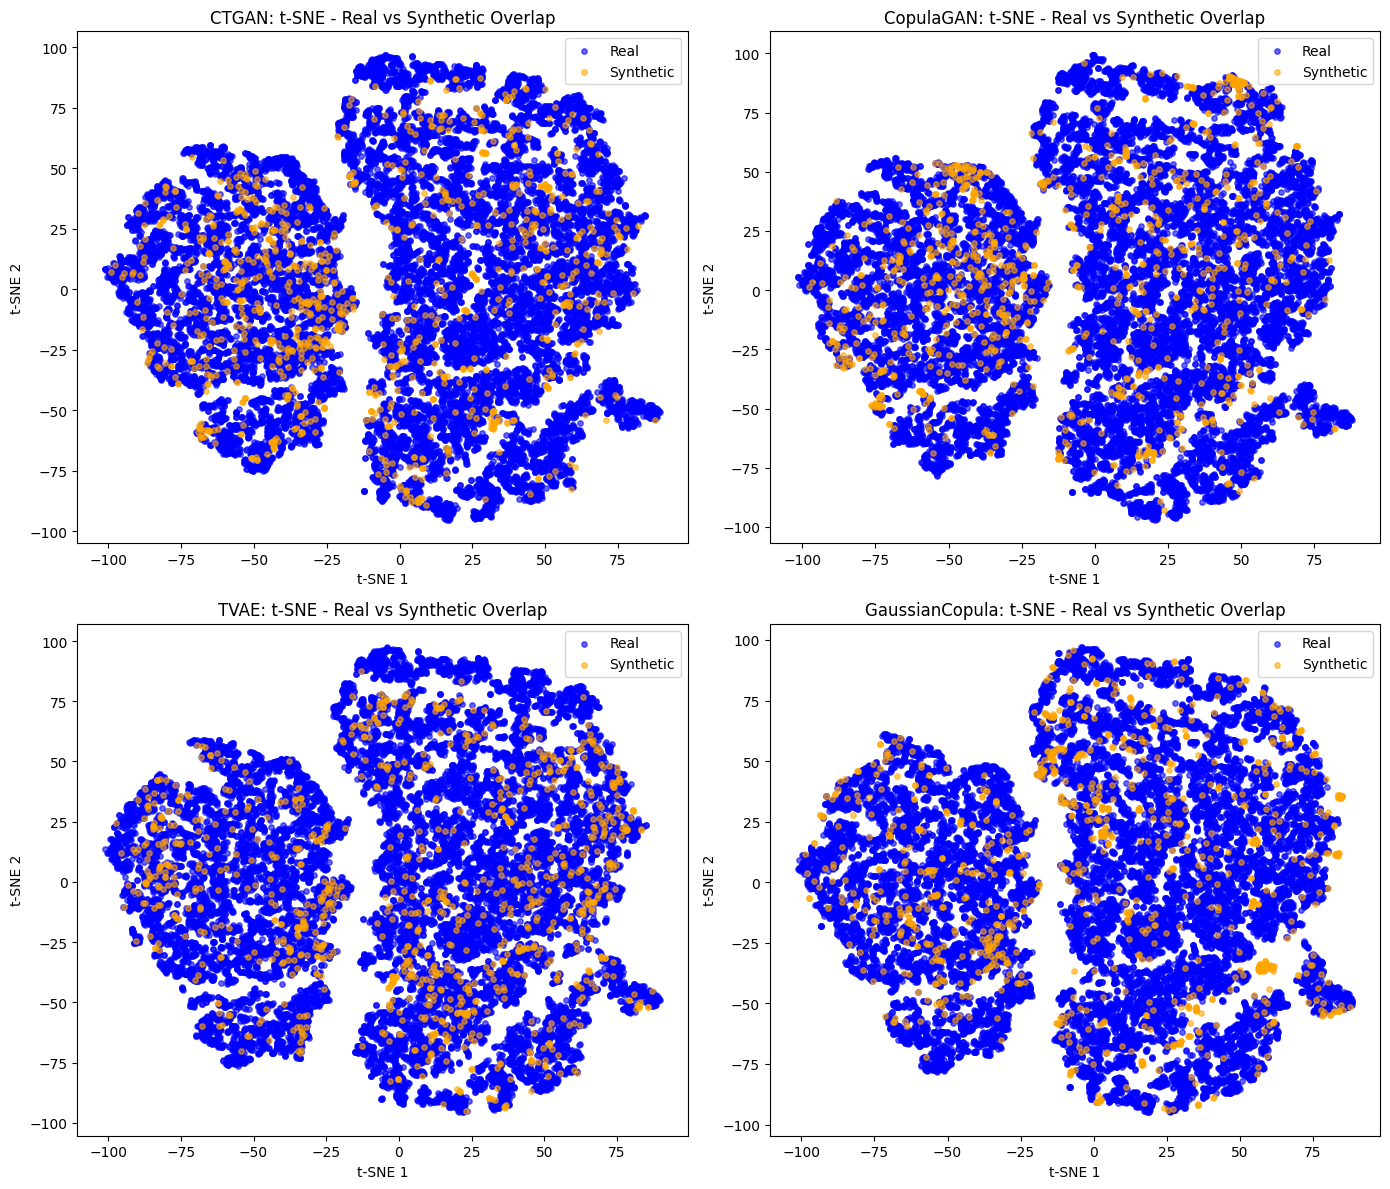

In [10]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

numeric_cols = real_data.select_dtypes(include="number").columns.tolist()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_data[numeric_cols]),
    columns=numeric_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name].copy()
    common_cols = [c for c in numeric_cols if c in synth_df.columns]
    synth_df = synth_df[common_cols]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=common_cols
    )

    combined = np.vstack([real_scaled[common_cols].values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()


#### 1.6 MMD (Maximum Mean Discrepancy)


In [13]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
import pandas as pd

def mmd_rbf_sampled(X, Y, gamma=None):
    """Unbiased MMD with RBF kernel on (possibly subsampled) arrays."""
    n, m = len(X), len(Y)
    if gamma is None:
        probe = np.vstack([X[: min(500, n)], Y[: min(500, m)]])
        d = np.sqrt(((probe[:, None, :] - probe[None, :, :]) ** 2).sum(-1))
        med = np.median(d[d > 0])
        gamma = 1.0 / (2 * (med ** 2 + 1e-12))

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    term_xx = (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1)) if n > 1 else 0.0
    term_yy = (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1)) if m > 1 else 0.0
    return float(term_xx + term_yy - 2 * Kxy.mean())

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_features = real_data.drop(columns=[target_col], errors="ignore")
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = metric_subsample_df(real_features[common_cols])
    X_synth = synth_features[common_cols].reset_index(drop=True)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_score = mmd_rbf_sampled(X_real_scaled, X_synth_scaled)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score (subsample n={len(X_real)}): {mmd_score:.4f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print(f"\nMMD comparison on up to {METRIC_SAMPLE_SIZE} real rows (lower is better):")
display(mmd_summary_df)


CTGAN - MMD score (subsample n=2000): 0.0092
CopulaGAN - MMD score (subsample n=2000): 0.0115
TVAE - MMD score (subsample n=2000): 0.0060
GaussianCopula - MMD score (subsample n=2000): 0.0174

MMD comparison on up to 2000 real rows (lower is better):


,Model,MMD_Score
0,TVAE,0.006045
1,CTGAN,0.009227
2,CopulaGAN,0.011489
3,GaussianCopula,0.017409


### 1.7 Cosine Similarity


In [14]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

real_data = magic_data.copy()
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_features = real_data.drop(columns=[target_col], errors="ignore")
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = metric_subsample_df(real_features[common_cols])
    X_synth = synth_features[common_cols].reset_index(drop=True)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = np.mean(cross_sim)
    max_sim = np.max(cross_sim)

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0282
Maximum cosine similarity: 0.9932

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: 0.0176
Maximum cosine similarity: 0.9909

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0330
Maximum cosine similarity: 0.9954

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0041
Maximum cosine similarity: 0.9957

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.033048,0.995427
1,CTGAN,0.028233,0.993171
2,CopulaGAN,0.017636,0.990898
3,GaussianCopula,0.004072,0.995706


#### 1.8 Nearest Neighbours


In [15]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

real_features = magic_data.drop(columns=[target_col], errors="ignore")
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]
    synth_features = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols]
    X_synth = synth_features[common_cols]

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)
    avg_nn_dist = np.mean(distances)
    min_nn_dist = np.min(distances)
    p5_nn_dist = np.percentile(distances, 5)

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)



CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.0642
Minimum NN Distance (Synthetic -> Real): 0.2711
5th Percentile NN Distance: 0.4528

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.1910
Minimum NN Distance (Synthetic -> Real): 0.2196
5th Percentile NN Distance: 0.4797

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.6046
Minimum NN Distance (Synthetic -> Real): 0.1861
5th Percentile NN Distance: 0.3141

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.4971
Minimum NN Distance (Synthetic -> Real): 0.3365
5th Percentile NN Distance: 0.6617

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,GaussianCopula,1.497070,0.336538,0.661676
1,CopulaGAN,1.191008,0.219554,0.479711
2,CTGAN,1.064176,0.271120,0.452793
3,TVAE,0.604633,0.186111,0.314096


# Stats 


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,368.927512,10.328742,5.349465
1,CopulaGAN,228.106995,9.026041,19.396021
2,TVAE,24.578524,4.897867,15.298178
3,GaussianCopula,38.653274,2.032016,14.455943


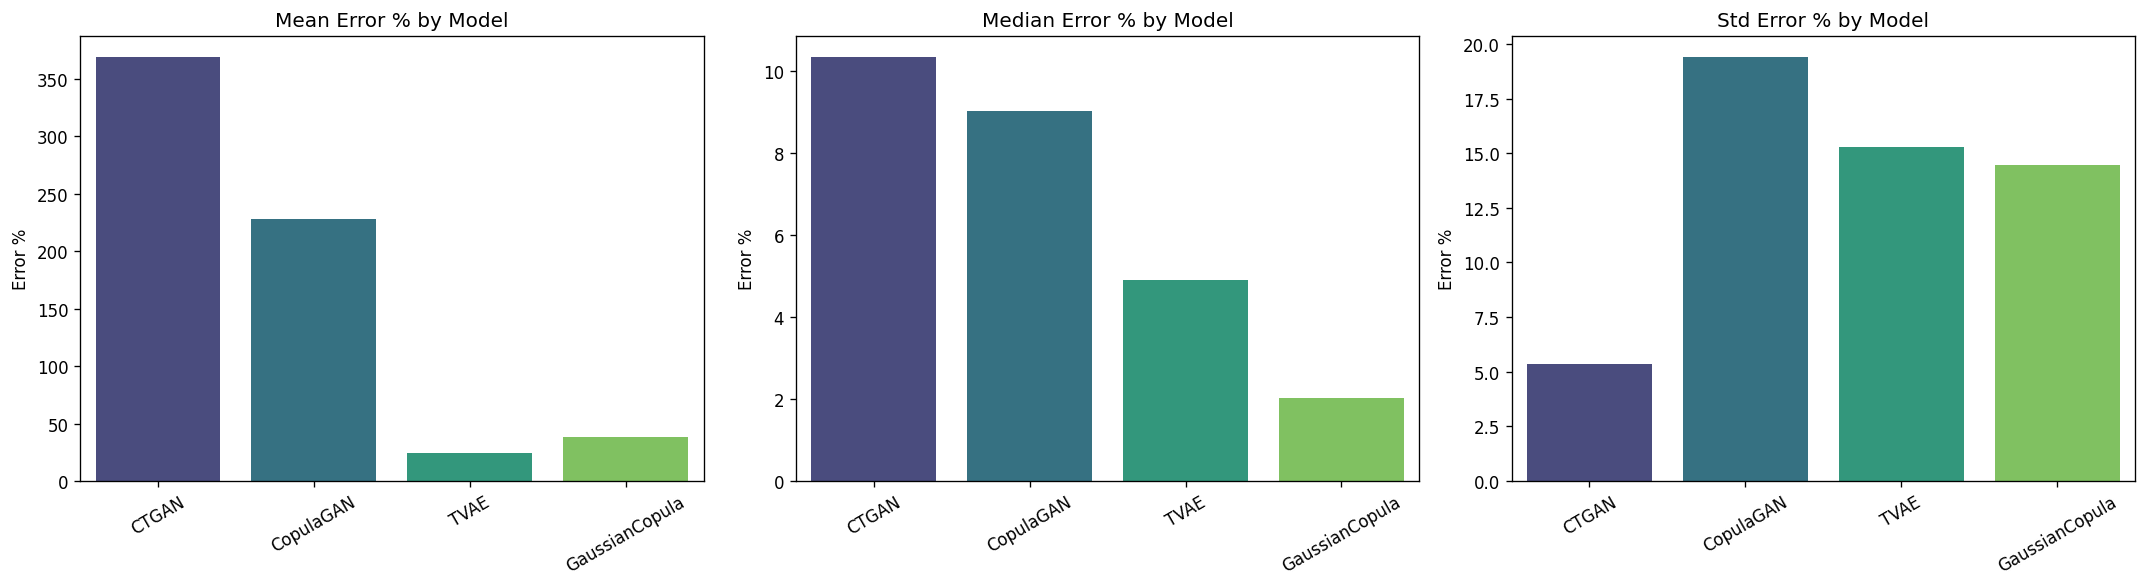

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = magic_data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
if "class" in num_cols:
    num_cols.remove("class")

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].mean()
    synth_means = synth_df[num_cols].mean()

    real_stds = real_df[num_cols].std(ddof=1)
    synth_stds = synth_df[num_cols].std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": feature_error_df["Mean_Error_%"].mean(skipna=True),
        "Median Error %": feature_error_df["Mean_Error_%"].median(skipna=True),
        "Std Error %": feature_error_df["Std_Error_%"].mean(skipna=True)
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


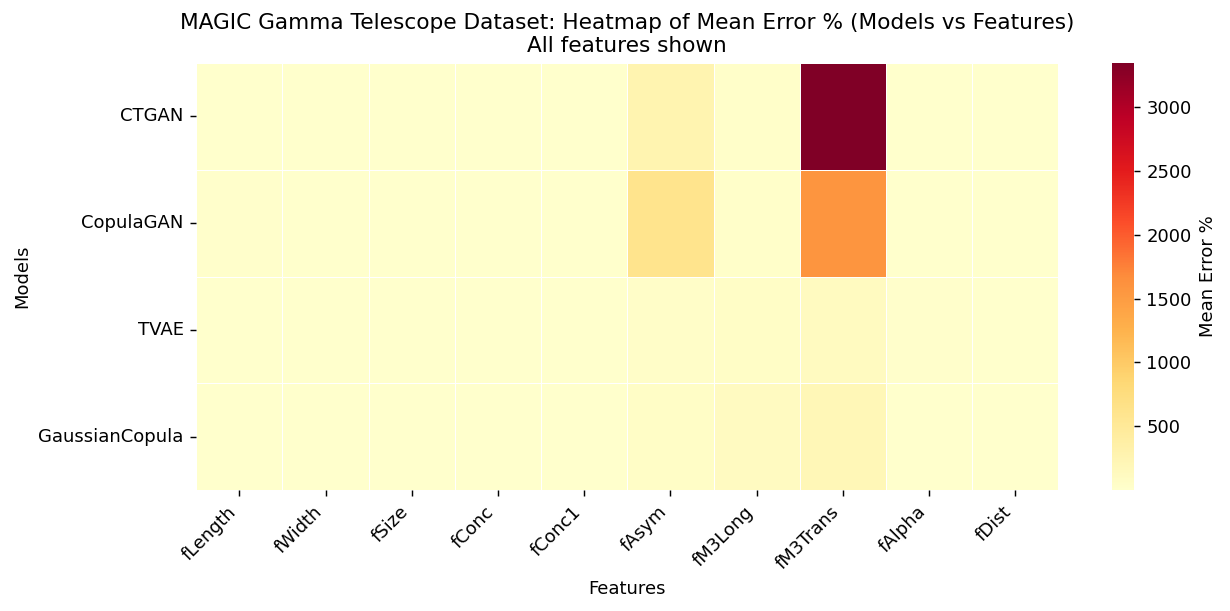

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"MAGIC Gamma Telescope Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


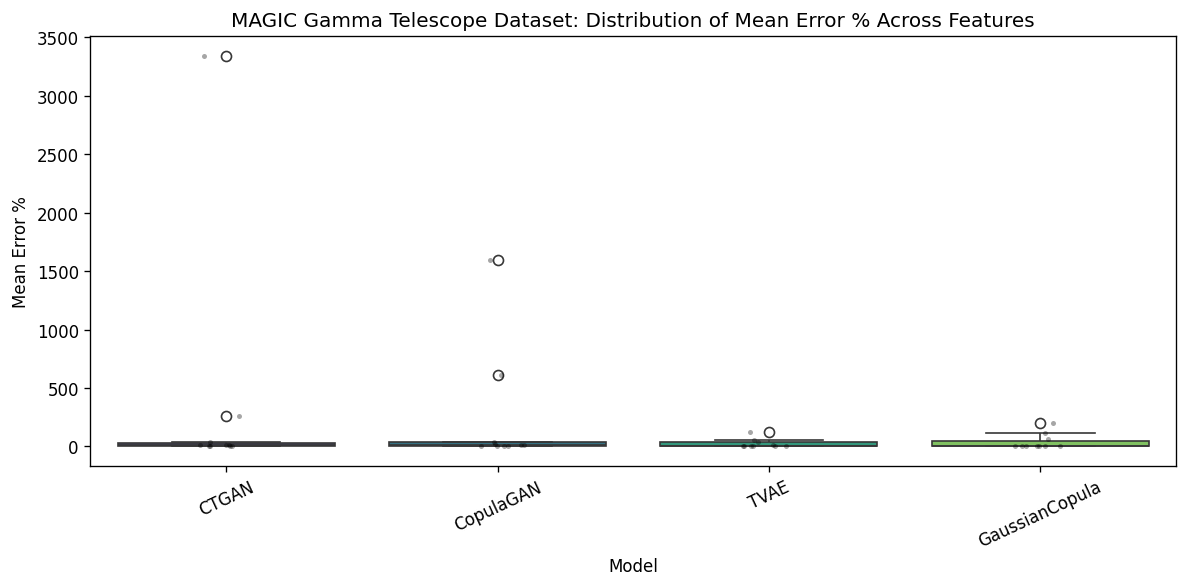

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("MAGIC Gamma Telescope Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


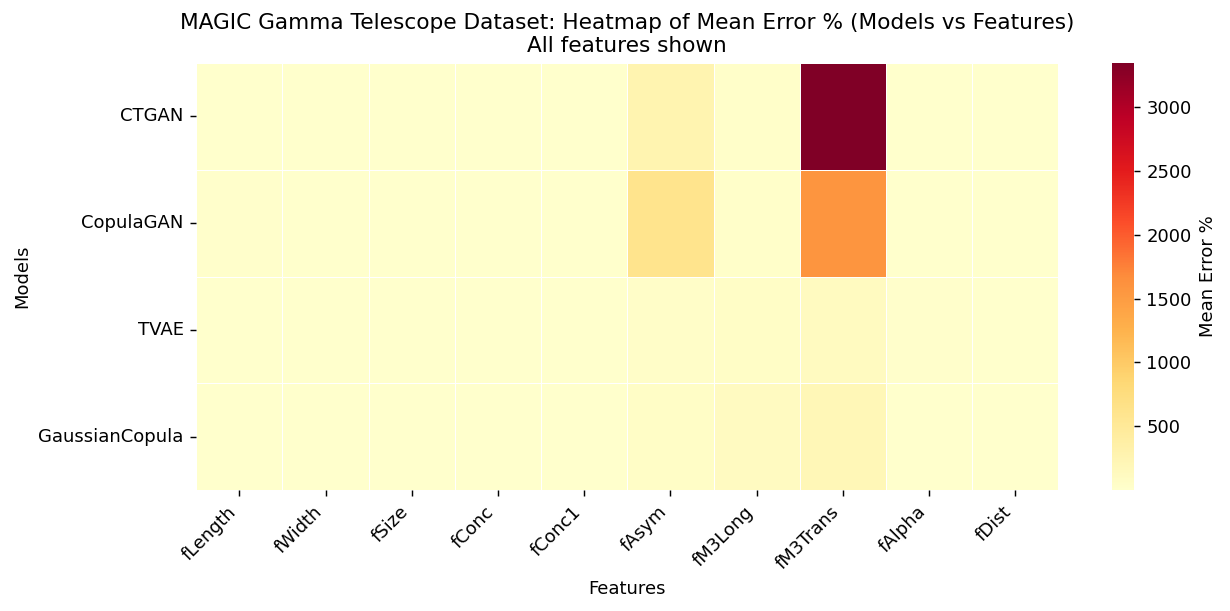

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"MAGIC Gamma Telescope Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# 2 Bivariate Analysis


In [20]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality(real_df, synth_df, target="class"):
    num_cols = [c for c in real_df.columns if c != target]

    scaler = MinMaxScaler()
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)

    return corr_df, target_df


In [21]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = magic_data.copy()

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    corr_results, target_results = bivariate_quality(
        real_df=real_df,
        synth_df=synth_df,
        target="class"
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by class (gamma/hadron):")
    display(target_results.head(10))
    print("=" * 60)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results["delta_corr"].iloc[0] if not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results["delta_corr"].head(10).mean() if not corr_results.empty else None,
        "TopTargetDiff": target_results["delta_wasserstein"].iloc[0] if not target_results.empty else None,
        "MeanTop10TargetDiff": target_results["delta_wasserstein"].head(10).mean() if not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
14,fWidth,fM3Trans,0.320199
21,fSize,fM3Trans,0.301503
6,fLength,fM3Trans,0.287688
27,fConc,fM3Trans,0.242694
32,fConc1,fM3Trans,0.217875
0,fLength,fWidth,0.204000
36,fAsym,fM3Trans,0.171647
7,fLength,fAlpha,0.161494
24,fConc,fConc1,0.158809
8,fLength,fDist,0.158086


CTGAN - Features that differ most by class (gamma/hadron):


,feature,delta_wasserstein
8,fAlpha,0.058657
0,fLength,0.016389
9,fDist,0.014361
1,fWidth,0.013405
2,fSize,0.012623
3,fConc,0.011804
5,fAsym,0.008926
7,fM3Trans,0.006411
6,fM3Long,0.005028
4,fConc1,0.002329



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
10,fWidth,fConc,0.117564
11,fWidth,fConc1,0.113152
13,fWidth,fM3Long,0.094977
5,fLength,fM3Long,0.093357
43,fM3Trans,fDist,0.076993
2,fLength,fConc,0.076256
3,fLength,fConc1,0.070118
15,fWidth,fAlpha,0.069855
4,fLength,fAsym,0.060522
1,fLength,fSize,0.058858


GaussianCopula - Features that differ most by class (gamma/hadron):


,feature,delta_wasserstein
8,fAlpha,0.113172
0,fLength,0.051194
1,fWidth,0.026554
7,fM3Trans,0.017495
6,fM3Long,0.013861
5,fAsym,0.009872
4,fConc1,0.008186
9,fDist,0.004907
2,fSize,0.000276
3,fConc,0.000229


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,0.320199,0.222400,0.058657,0.014993
1,CopulaGAN,0.789704,0.472731,0.077683,0.014379
2,TVAE,0.315617,0.157268,0.035014,0.014962
3,GaussianCopula,0.117564,0.083165,0.113172,0.024575


# 3 Multivariate Analysis


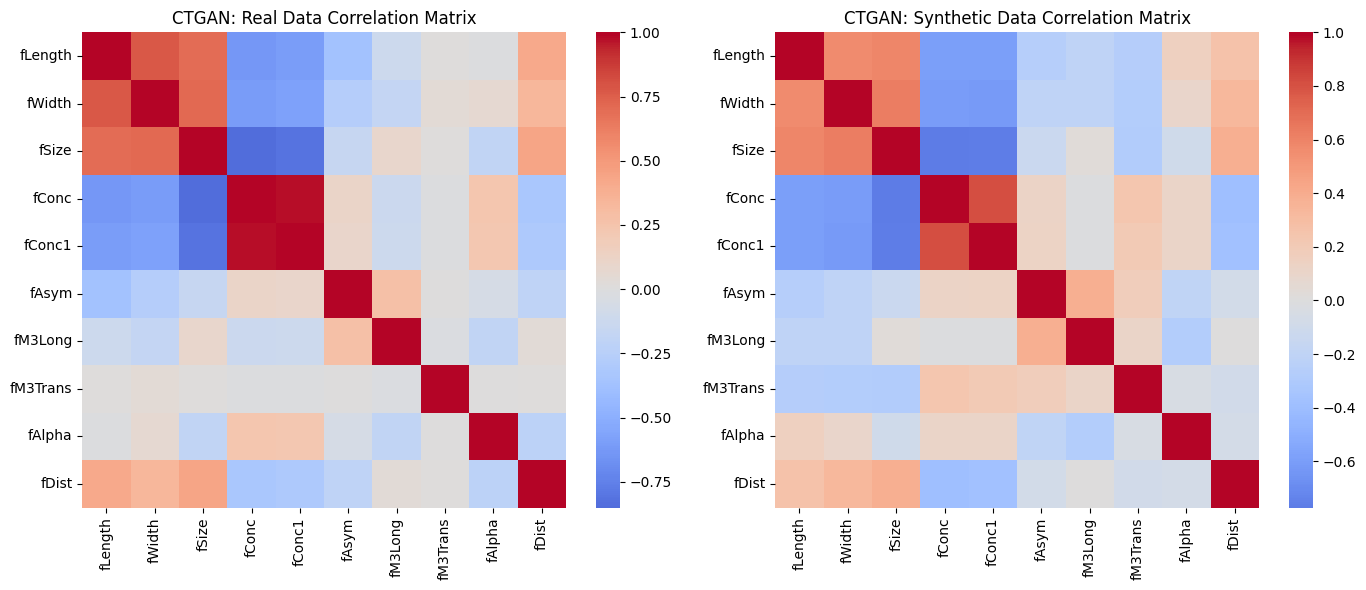

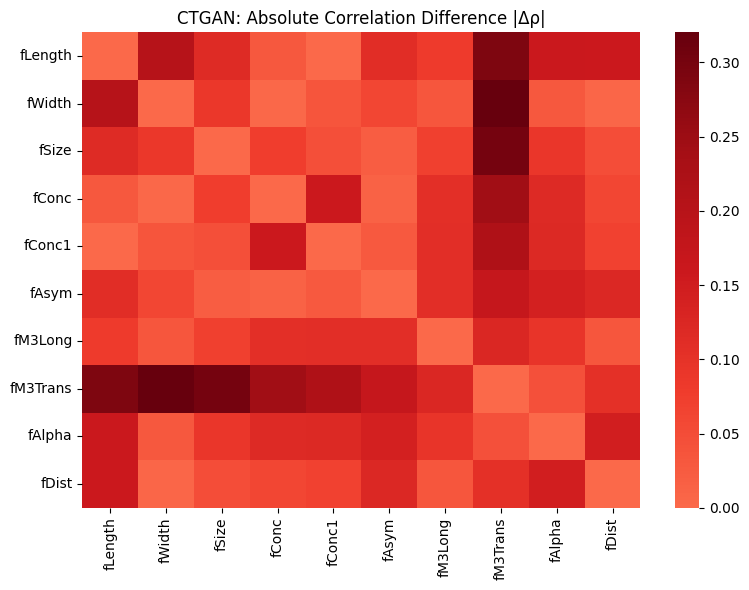

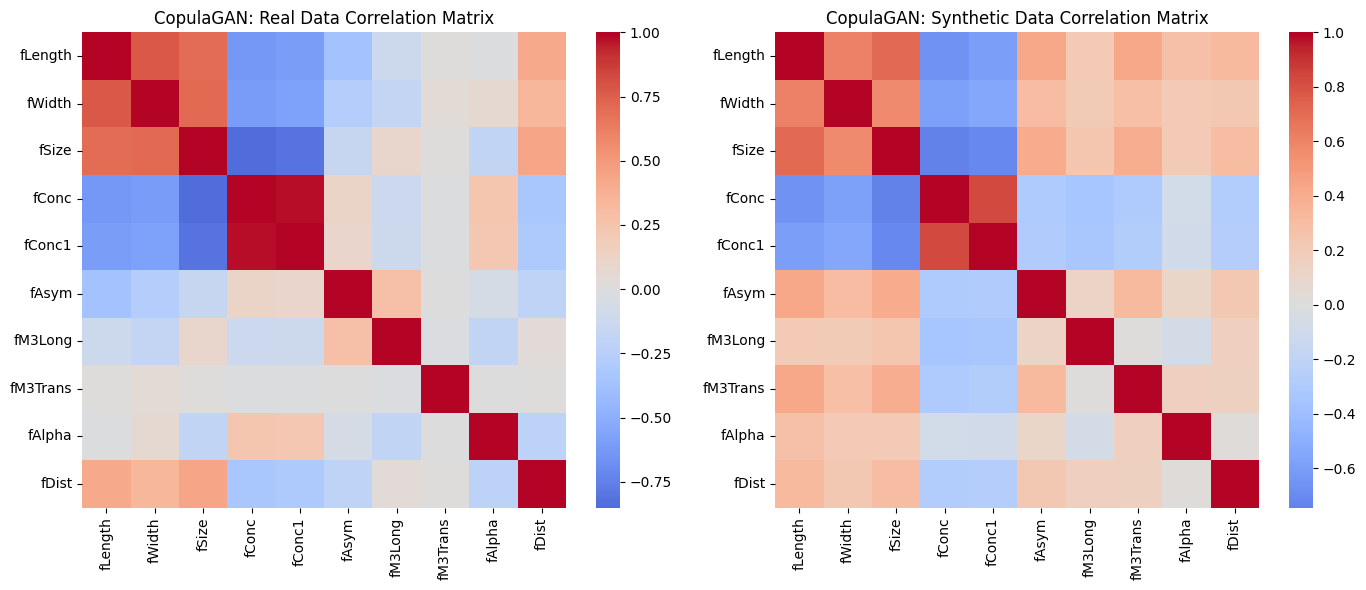

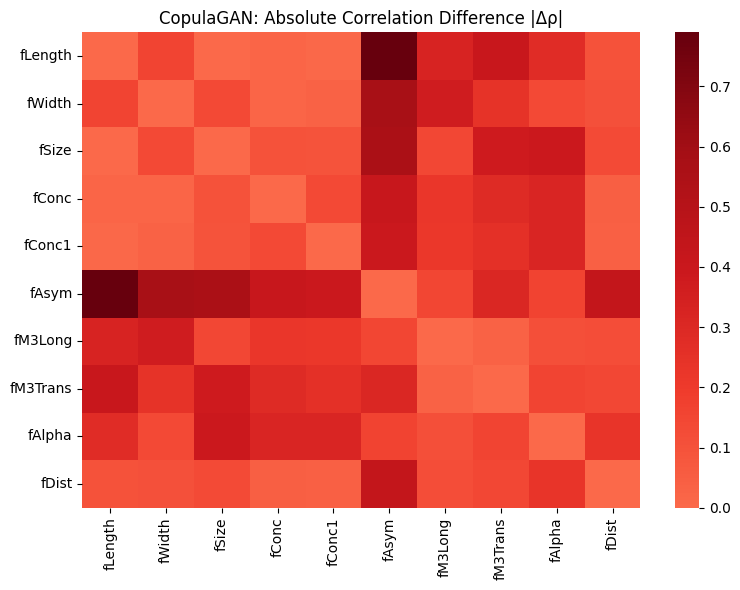

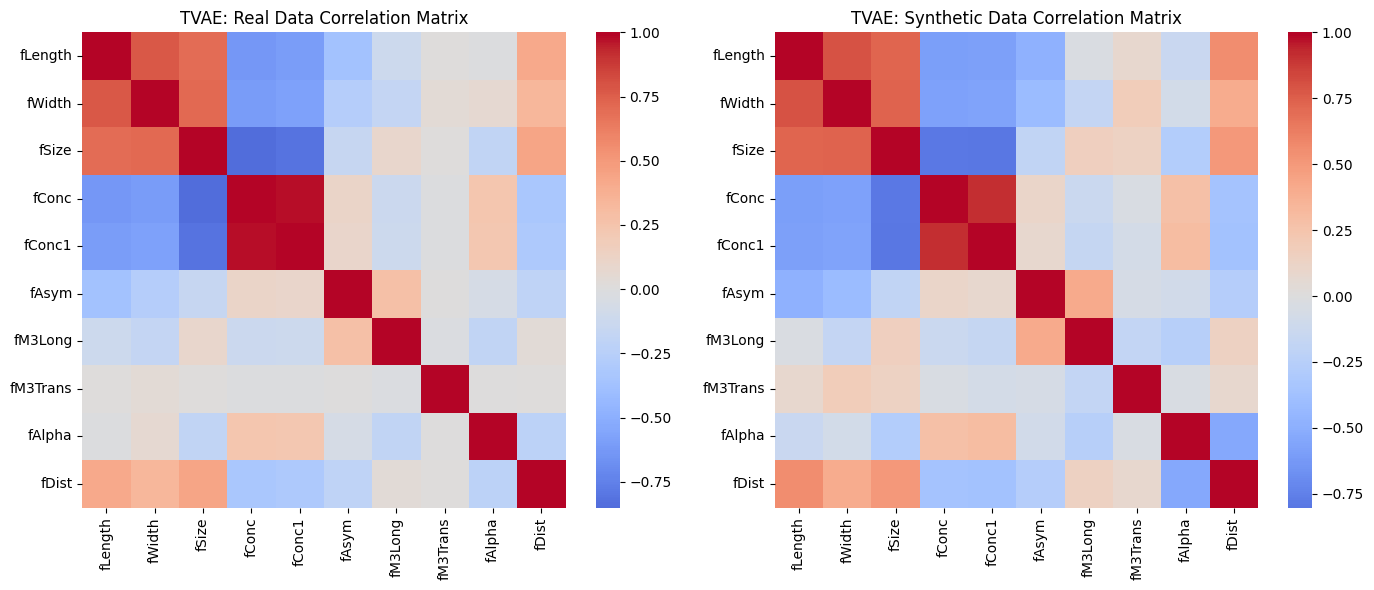

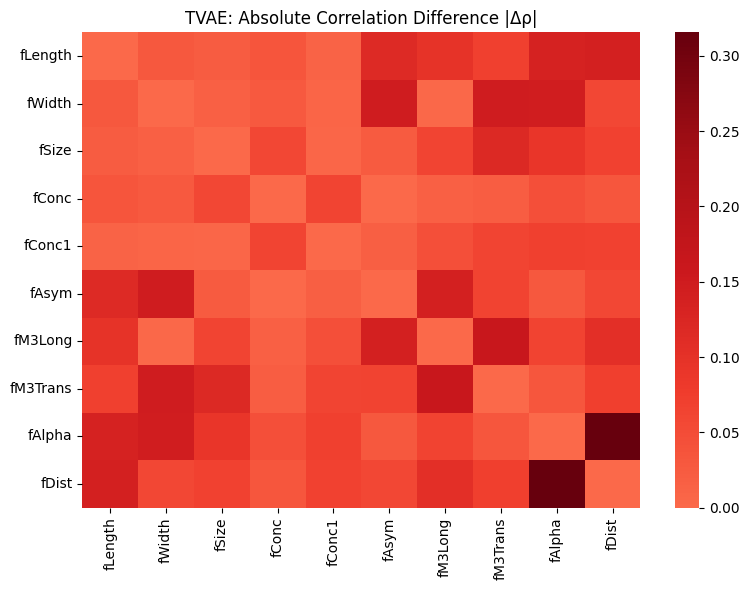

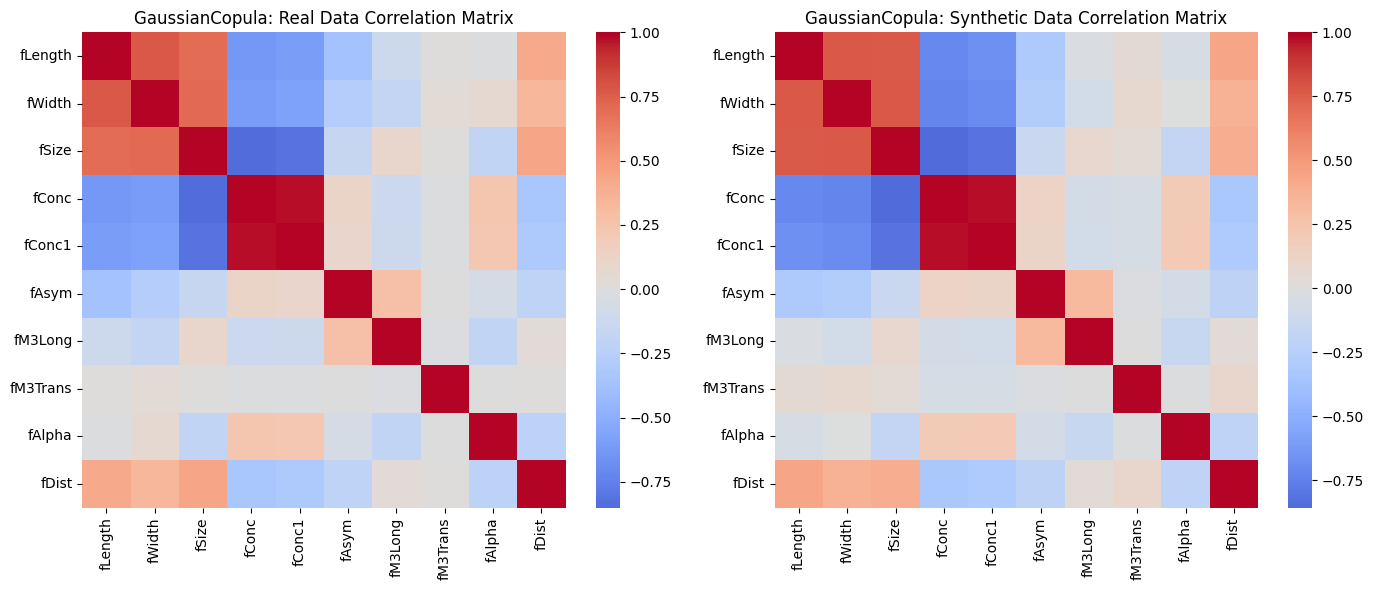

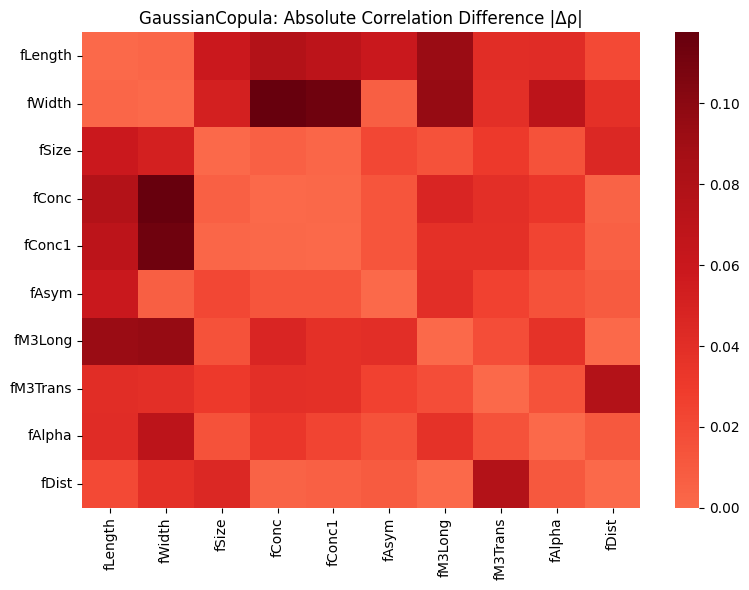

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = magic_data.copy()
num_cols = [c for c in real_df.columns if c != "class"]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.009336


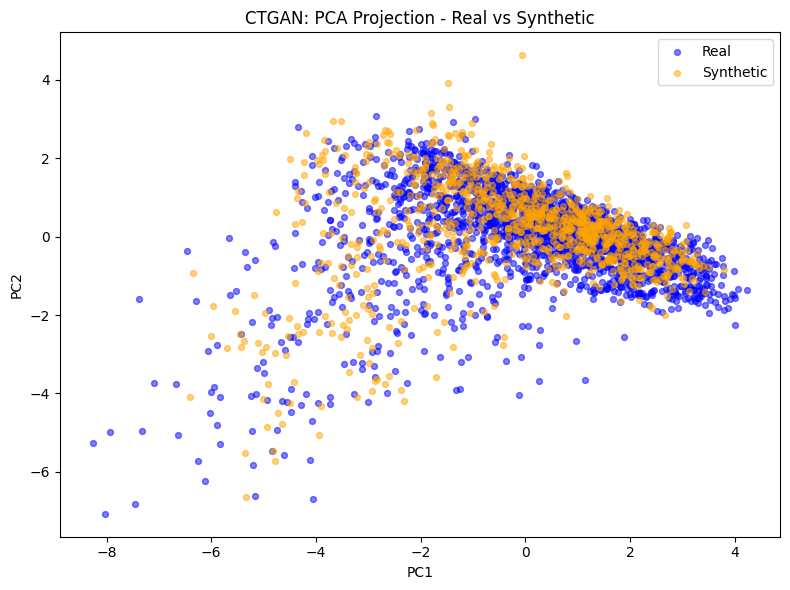

CTGAN - Two-Sample Classifier Accuracy: 0.8389

CopulaGAN - Global MMD (RBF): 0.012128


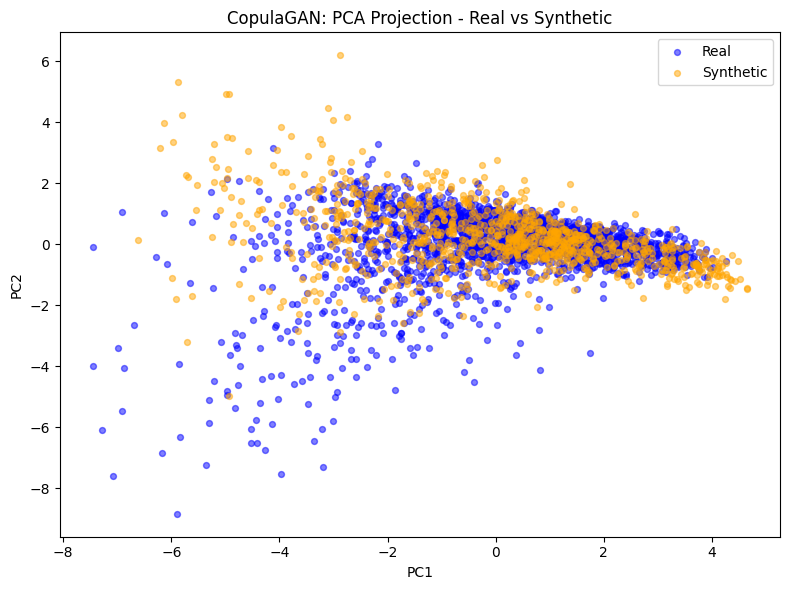

CopulaGAN - Two-Sample Classifier Accuracy: 0.8833

TVAE - Global MMD (RBF): 0.005462


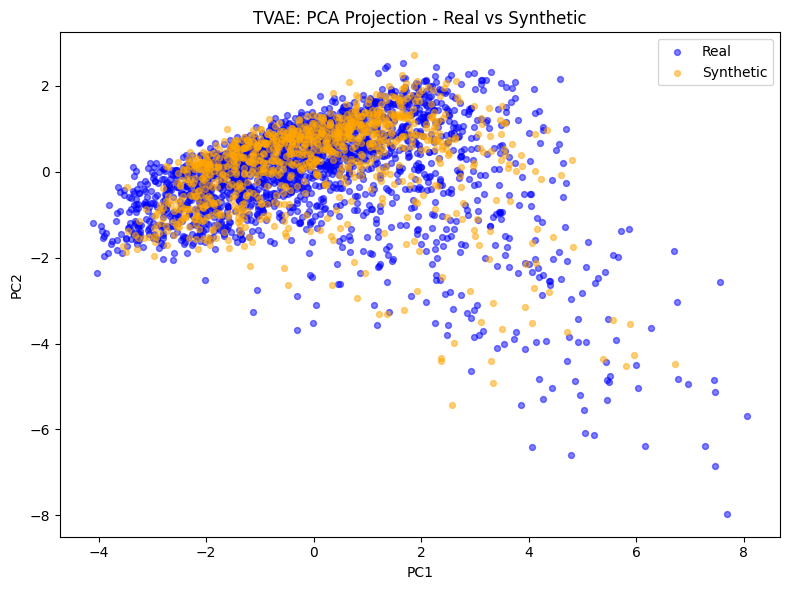

TVAE - Two-Sample Classifier Accuracy: 0.7678

GaussianCopula - Global MMD (RBF): 0.024400


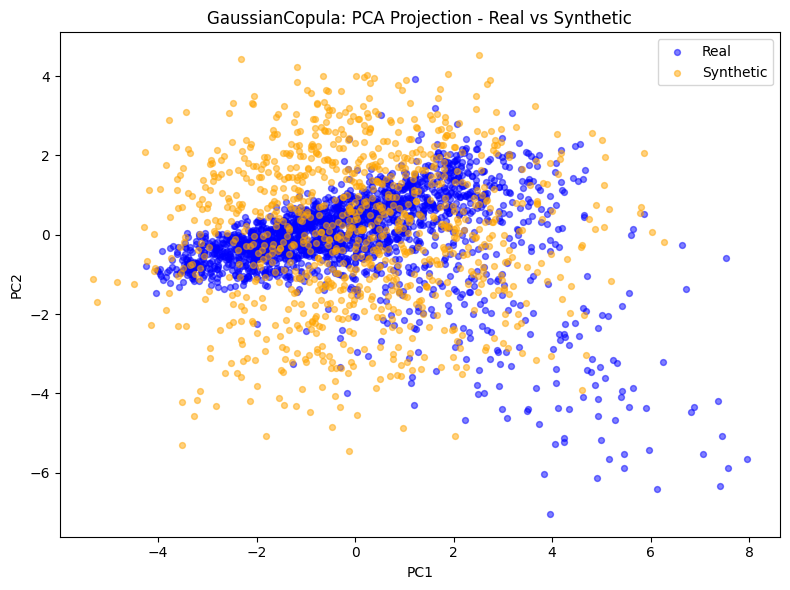

GaussianCopula - Two-Sample Classifier Accuracy: 0.9167

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,TVAE,0.005462,0.767778
1,CTGAN,0.009336,0.838889
2,CopulaGAN,0.012128,0.883333
3,GaussianCopula,0.024400,0.916667


In [23]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def mmd_rbf(X, Y, gamma=None):
    if gamma is None:
        Z = np.vstack([X, Y])
        probe = Z[: min(1000, len(Z))]
        dists = np.sqrt(((probe[:, None, :] - probe[None, :, :]) ** 2).sum(-1))
        med = np.median(dists[dists > 0])
        gamma = 1.0 / (2 * (med ** 2))
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)
    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "class"

X_real_df = magic_data.drop(columns=[target_col], errors="ignore")
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=[target_col], errors="ignore")

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = metric_subsample_df(X_real_df[common_cols]).values
    X_synth = X_synth_df[common_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": mmd_value,
        "C2ST_Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 classifiers


In [24]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

models = {
    "LogReg": LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
    "SVM-RBF": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

def evaluate_models(train_df, test_df, label_col="Group", models=models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)
        y_pred = clf.predict(X_test_s)

        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)


In [25]:
import pandas as pd

label_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=magic_data,
    test_df=magic_data,
    label="class",
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=magic_data,
        label="class",
        models=models
    )

    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )

    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]

    if "F1_TRTR" in comparison.columns and "F1_TSTR" in comparison.columns:
        comparison["F1_Drop"] = comparison["F1_TRTR"] - comparison["F1_TSTR"]
    if "Accuracy_TRTR" in comparison.columns and "Accuracy_TSTR" in comparison.columns:
        comparison["Accuracy_Drop"] = comparison["Accuracy_TRTR"] - comparison["Accuracy_TSTR"]

    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("AUC_Drop", ascending=False)

    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)

    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)

summary = (
    combined_comparison
    .groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("Average AUC drop by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
9,MLP,0.882229,0.912568,0.937465
5,RandomForest,0.885910,0.914768,0.937432
6,ExtraTrees,0.883018,0.913306,0.936314
7,GradientBoost,0.876709,0.909442,0.925083
1,SVM-RBF,0.868559,0.904031,0.921035
8,AdaBoost,0.825973,0.870043,0.879710
2,KNN,0.836225,0.881671,0.879532
0,LogReg,0.783649,0.843863,0.831260
4,DecisionTree,0.813354,0.855867,0.795873
3,NaiveBayes,0.729758,0.814440,0.748789


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.744479,0.784574,0.833550
1,SVM-RBF,0.736330,0.778146,0.826985
5,RandomForest,0.702944,0.737209,0.817063
9,MLP,0.684543,0.720800,0.800084
7,GradientBoost,0.690326,0.725280,0.795353
8,AdaBoost,0.684543,0.719626,0.795159
0,LogReg,0.704784,0.749944,0.788831
2,KNN,0.705310,0.757202,0.758459
3,NaiveBayes,0.723975,0.792981,0.748855
4,DecisionTree,0.601472,0.642453,0.622195


CTGAN - TRTR vs TSTR Comparison


...

,Model,Accuracy,F1,AUC
0,LogReg,0.728707,0.820647,0.791547
5,RandomForest,0.722135,0.815048,0.791219
1,SVM-RBF,0.676130,0.798429,0.781971
8,AdaBoost,0.733176,0.821836,0.779148
7,GradientBoost,0.723449,0.812344,0.758873
6,ExtraTrees,0.710831,0.808229,0.758331
3,NaiveBayes,0.751577,0.831340,0.738996
2,KNN,0.680862,0.777574,0.670274
9,MLP,0.669558,0.761072,0.636628
4,DecisionTree,0.613039,0.718116,0.550948


GaussianCopula - TRTR vs TSTR Comparison


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop,F1_Drop,Accuracy_Drop,Synthetic_Model
0,MLP,0.882229,0.912568,0.937465,0.669558,0.761072,0.636628,0.300836,0.151496,0.212671,GaussianCopula
8,DecisionTree,0.813354,0.855867,0.795873,0.613039,0.718116,0.550948,0.244926,0.137751,0.200315,GaussianCopula
6,KNN,0.836225,0.881671,0.879532,0.680862,0.777574,0.670274,0.209258,0.104097,0.155363,GaussianCopula
2,ExtraTrees,0.883018,0.913306,0.936314,0.710831,0.808229,0.758331,0.177982,0.105077,0.172187,GaussianCopula
3,GradientBoost,0.876709,0.909442,0.925083,0.723449,0.812344,0.758873,0.166210,0.097098,0.153260,GaussianCopula
1,RandomForest,0.885910,0.914768,0.937432,0.722135,0.815048,0.791219,0.146213,0.099720,0.163775,GaussianCopula
4,SVM-RBF,0.868559,0.904031,0.921035,0.676130,0.798429,0.781971,0.139063,0.105601,0.192429,GaussianCopula
5,AdaBoost,0.825973,0.870043,0.879710,0.733176,0.821836,0.779148,0.100562,0.048207,0.092797,GaussianCopula
7,LogReg,0.783649,0.843863,0.831260,0.728707,0.820647,0.791547,0.039713,0.023216,0.054942,GaussianCopula
9,NaiveBayes,0.729758,0.814440,0.748789,0.751577,0.831340,0.738996,0.009793,-0.016900,-0.021819,GaussianCopula


Average AUC drop by synthetic generator (lower is better):


,Synthetic_Model,AUC_Drop
3,TVAE,0.046905
1,CopulaGAN,0.097882
0,CTGAN,0.100596
2,GaussianCopula,0.153456



CTGAN - TSTR


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.744479,0.784574,0.833550
1,SVM-RBF,0.736330,0.778146,0.826985
5,RandomForest,0.702944,0.737209,0.817063
9,MLP,0.684543,0.720800,0.800084
7,GradientBoost,0.690326,0.725280,0.795353
8,AdaBoost,0.684543,0.719626,0.795159
0,LogReg,0.704784,0.749944,0.788831
2,KNN,0.705310,0.757202,0.758459
3,NaiveBayes,0.723975,0.792981,0.748855
4,DecisionTree,0.601472,0.642453,0.622195


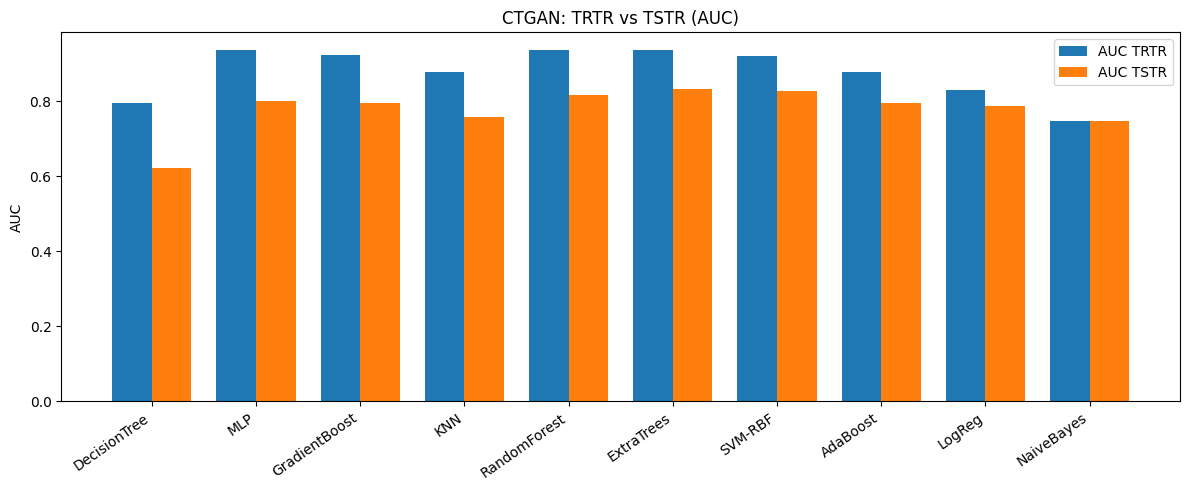

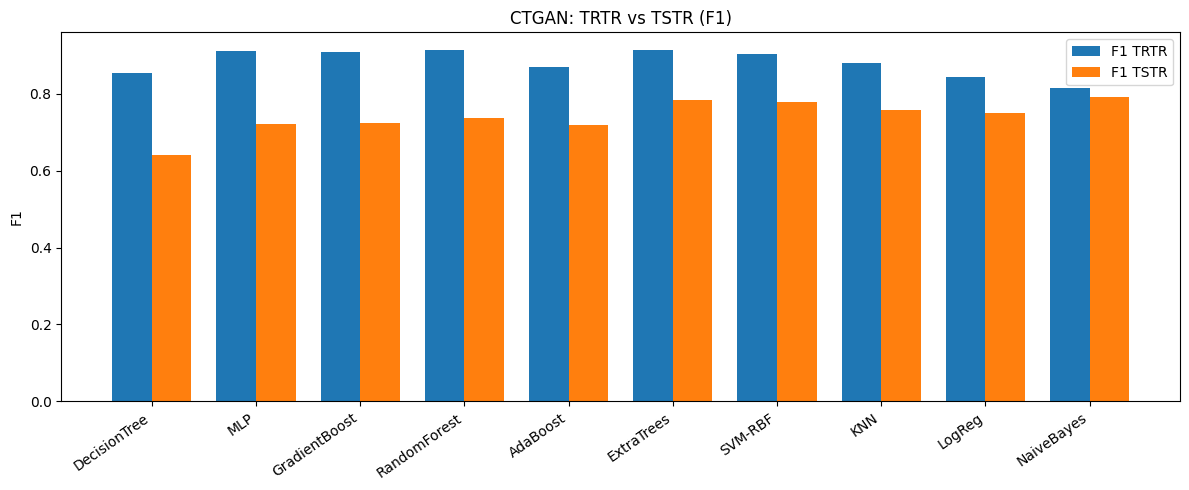

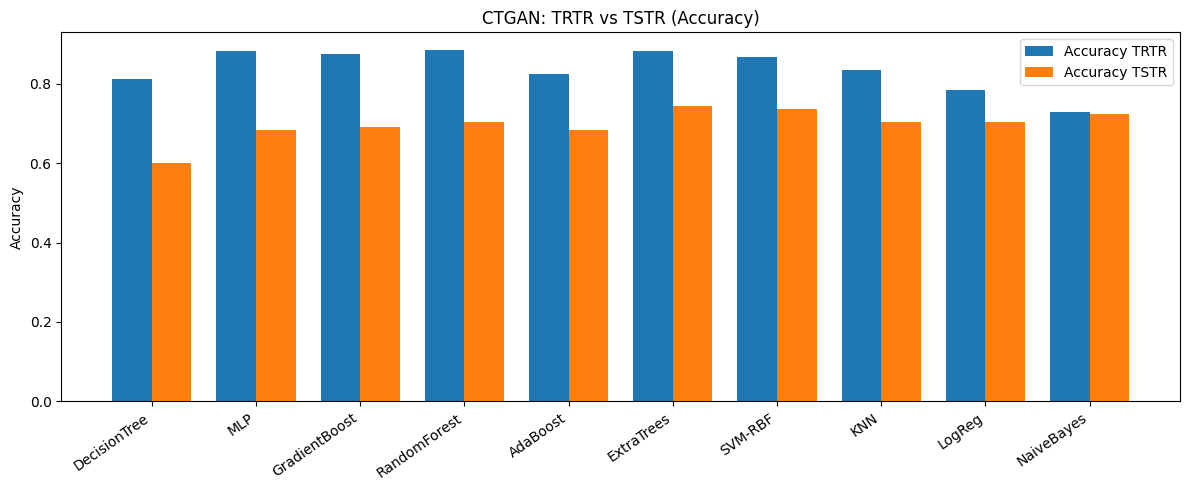

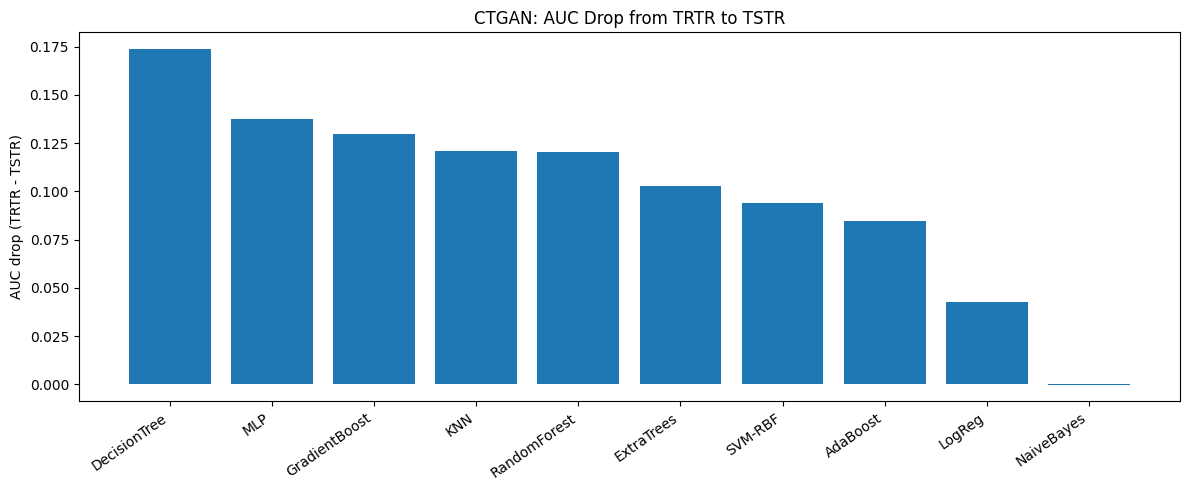


CopulaGAN - TSTR


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.759989,0.808796,0.822661
7,GradientBoost,0.743165,0.794012,0.816709
5,RandomForest,0.746845,0.795585,0.814081
1,SVM-RBF,0.759464,0.808777,0.812706
8,AdaBoost,0.732124,0.781565,0.802929
9,MLP,0.720294,0.770294,0.791899
0,LogReg,0.738170,0.799517,0.791625
3,NaiveBayes,0.751577,0.824317,0.771997
2,KNN,0.717403,0.780746,0.755445
4,DecisionTree,0.642219,0.705984,0.633623


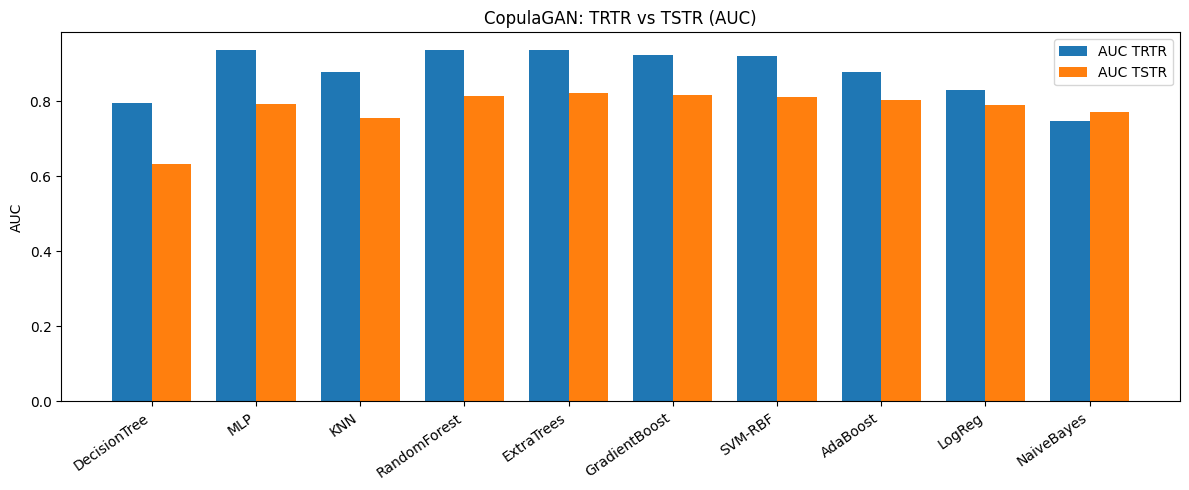

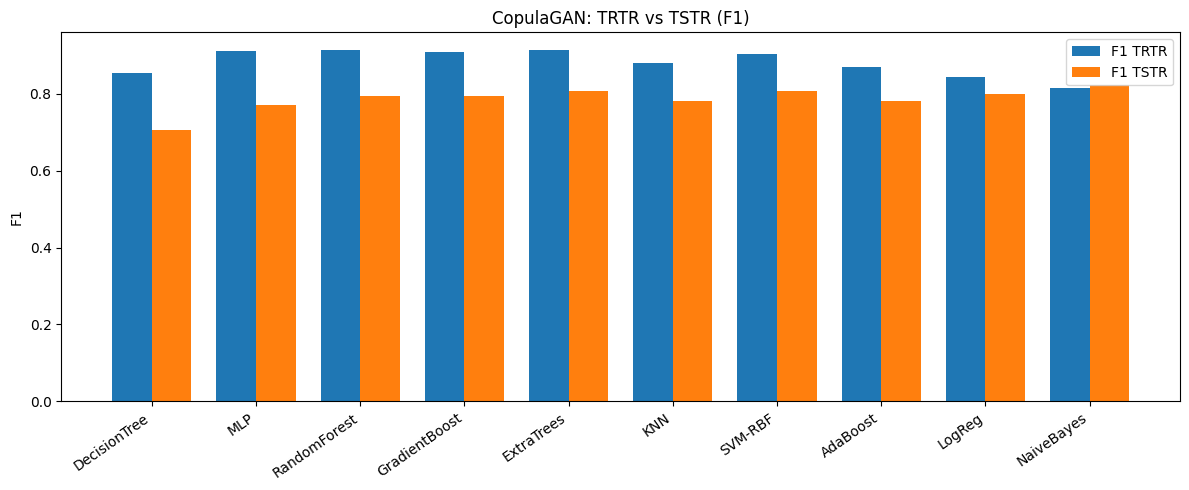

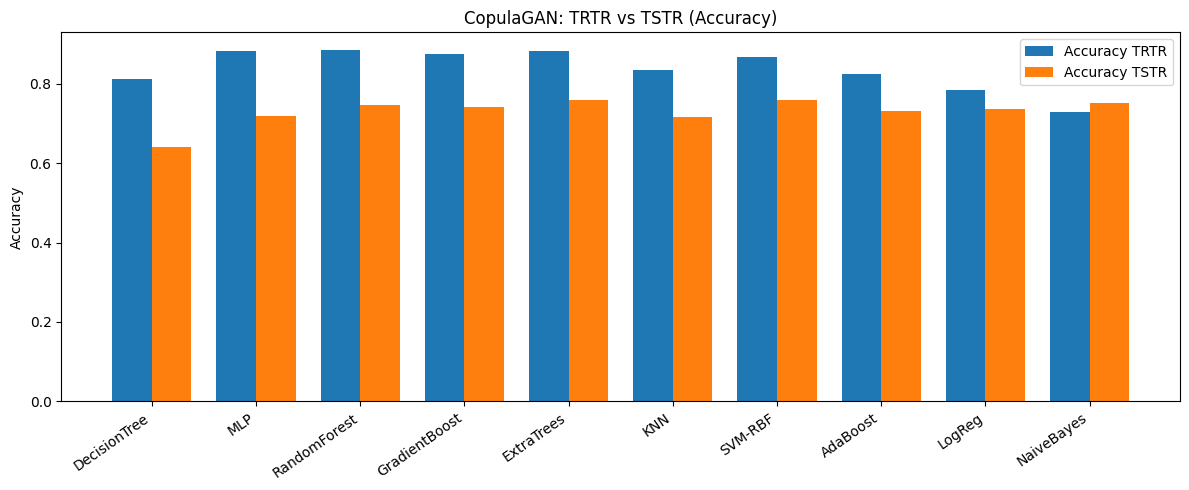

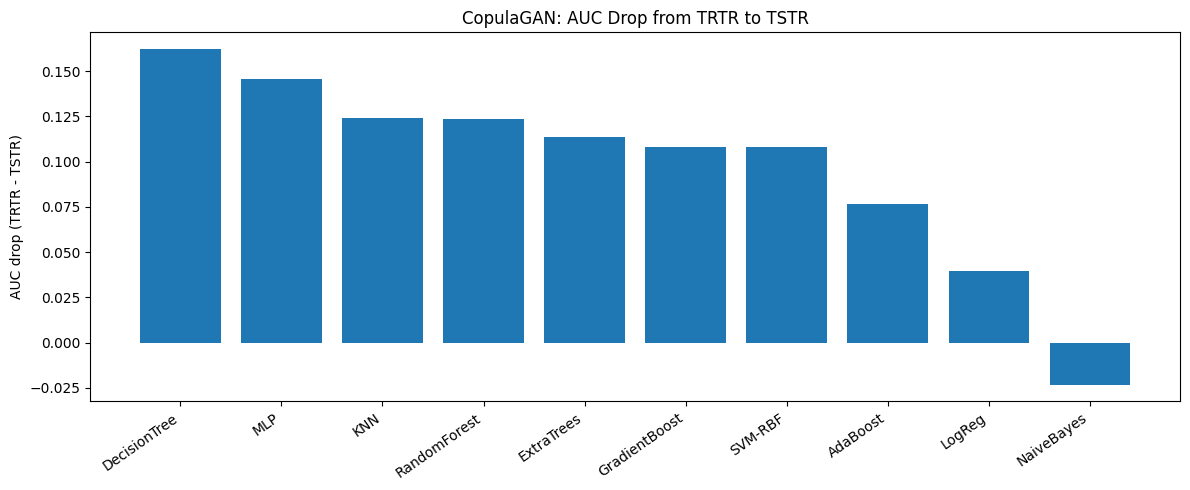


TVAE - TSTR


,Model,Accuracy,F1,AUC
5,RandomForest,0.814932,0.857085,0.876597
6,ExtraTrees,0.822029,0.864951,0.875878
9,MLP,0.807834,0.850664,0.866057
1,SVM-RBF,0.817823,0.862799,0.862096
7,GradientBoost,0.810200,0.856118,0.861138
8,AdaBoost,0.803365,0.850699,0.851367
2,KNN,0.781020,0.838409,0.804508
0,LogReg,0.768927,0.827139,0.794105
3,NaiveBayes,0.748160,0.816826,0.778512
4,DecisionTree,0.769979,0.820292,0.753188


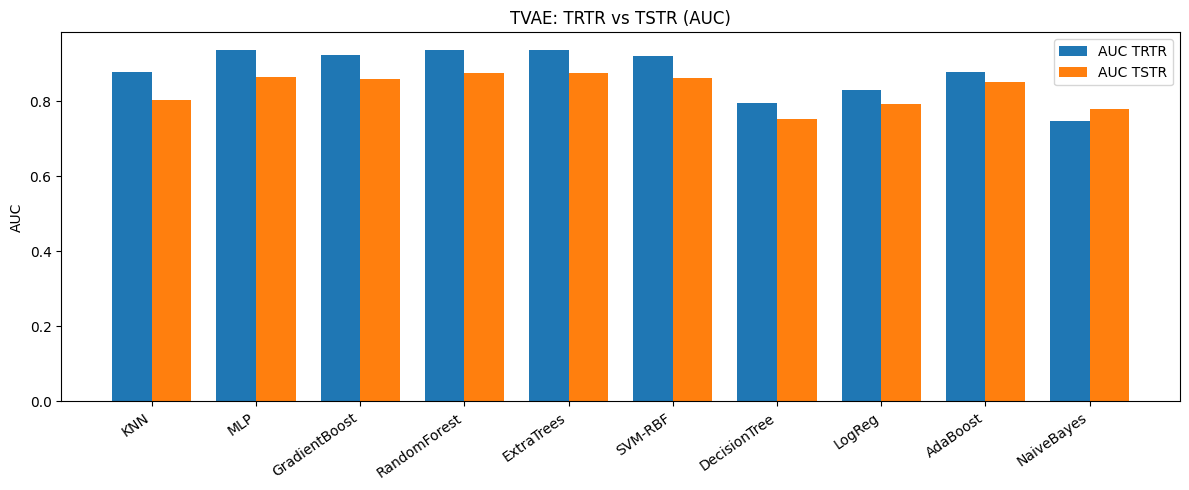

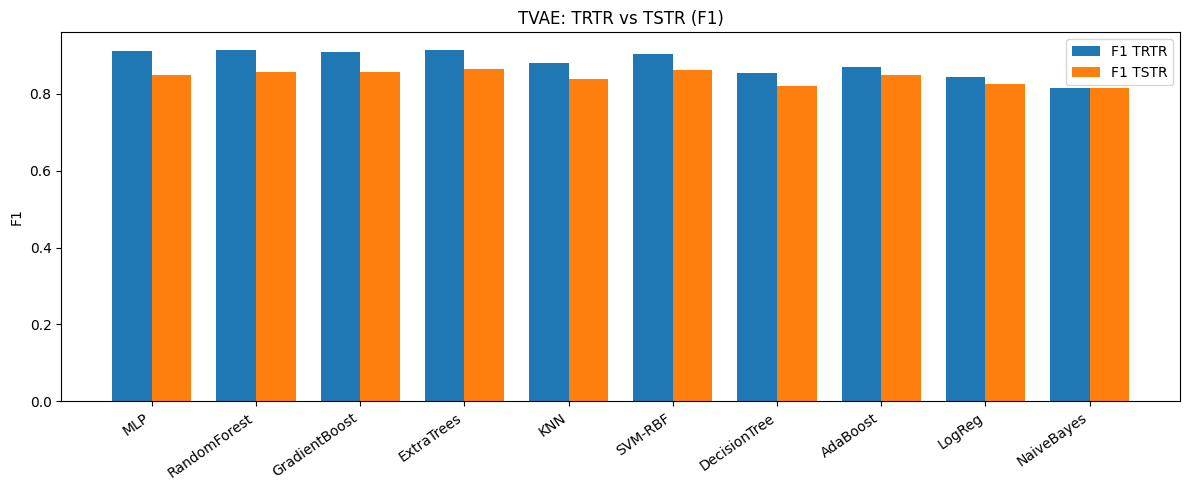

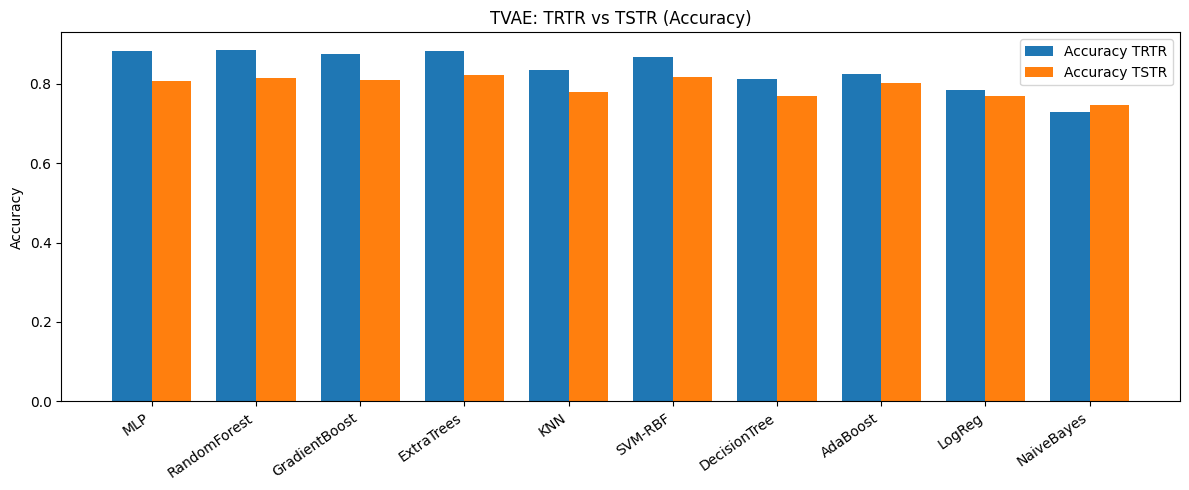

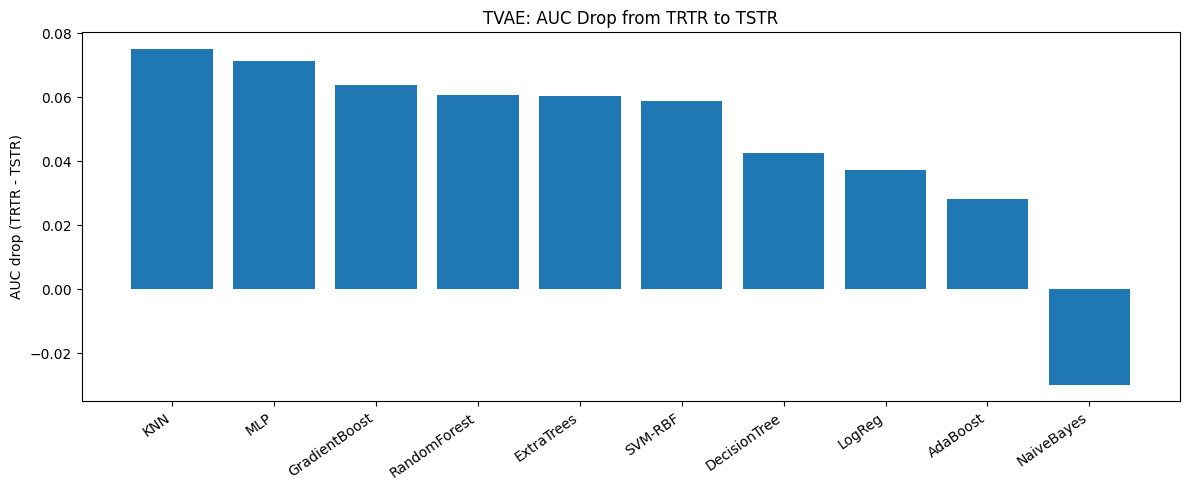


GaussianCopula - TSTR


,Model,Accuracy,F1,AUC
0,LogReg,0.728707,0.820647,0.791547
5,RandomForest,0.722135,0.815048,0.791219
1,SVM-RBF,0.676130,0.798429,0.781971
8,AdaBoost,0.733176,0.821836,0.779148
7,GradientBoost,0.723449,0.812344,0.758873
6,ExtraTrees,0.710831,0.808229,0.758331
3,NaiveBayes,0.751577,0.831340,0.738996
2,KNN,0.680862,0.777574,0.670274
9,MLP,0.669558,0.761072,0.636628
4,DecisionTree,0.613039,0.718116,0.550948


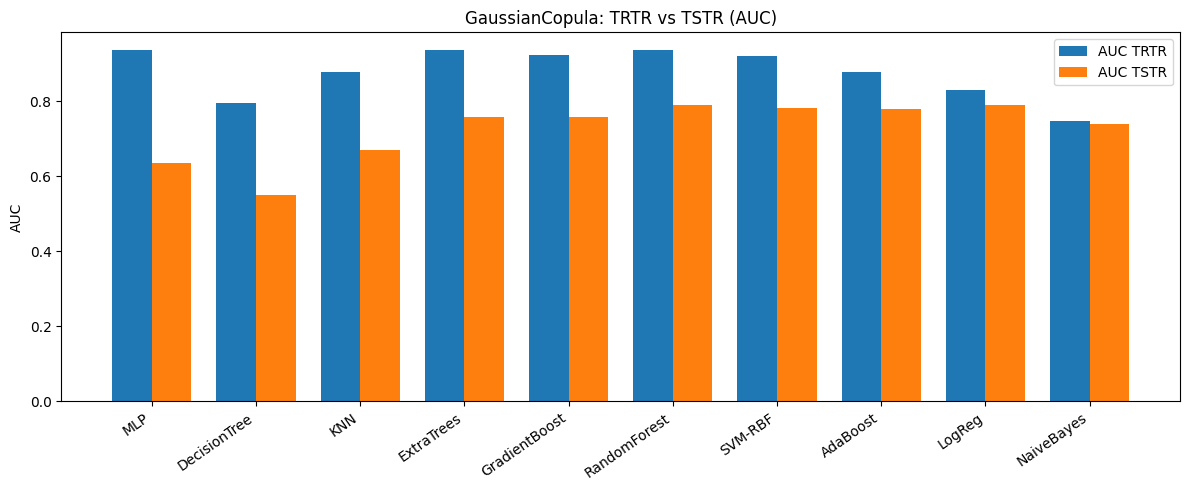

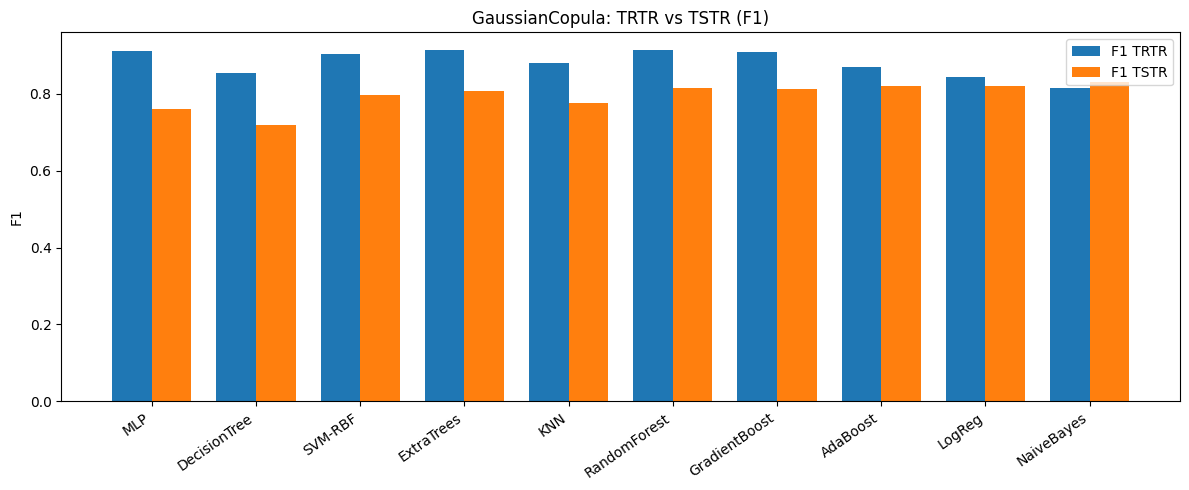

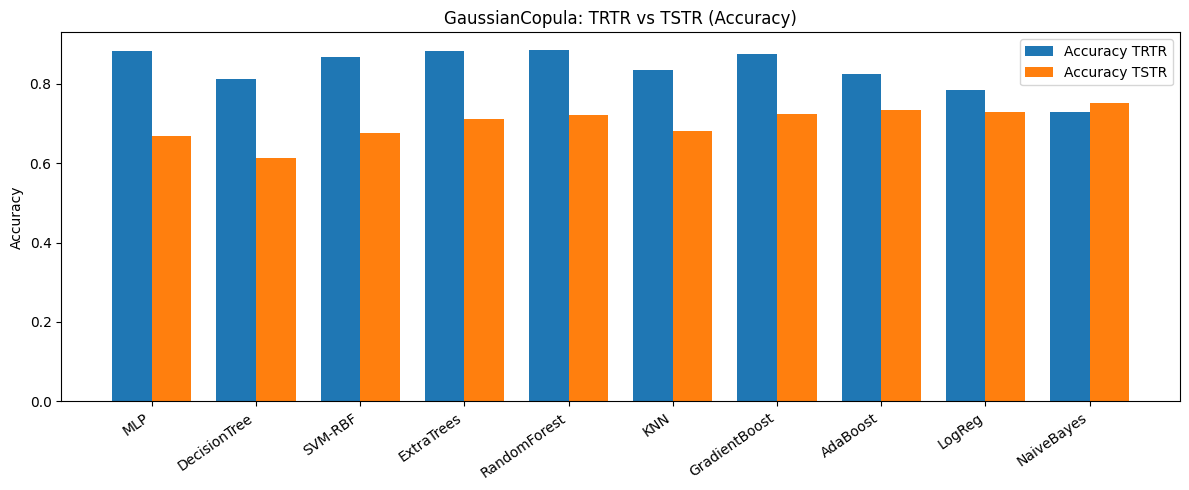

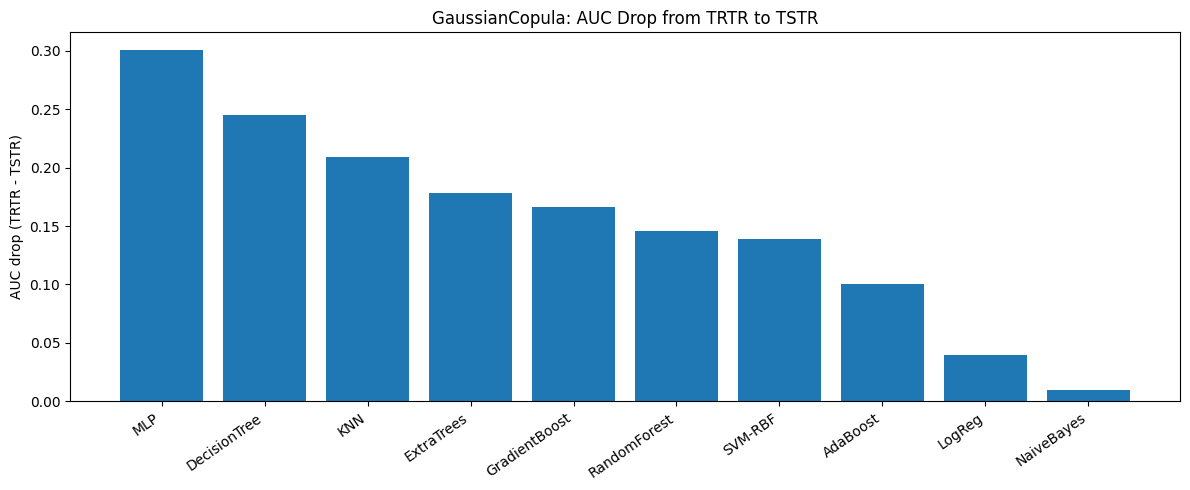


Average AUC drop by synthetic generator:


,Synthetic_Model,AUC_Drop
3,TVAE,0.046905
1,CopulaGAN,0.097882
0,CTGAN,0.100596
2,GaussianCopula,0.153456


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="AUC"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return

    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]],
        on="Model",
        suffixes=("_TRTR", "_TSTR")
    )
    df["Drop"] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values("Drop", ascending=False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w / 2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df, synth_name):
    if "AUC_Drop" not in comparison_df.columns:
        return

    df = comparison_df.sort_values("AUC_Drop", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(12, 5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title(f"{synth_name}: AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()

label_col = "class"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=magic_data,
    test_df=magic_data,
    label="class",
    models=models
)

all_comp = []

for synth_name in model_order:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[synth_name],
        test_df=magic_data,
        label="class",
        models=models
    )

    comparison = trtr_results.merge(
        tstr_results, on="Model", suffixes=("_TRTR", "_TSTR")
    )
    comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    all_comp.append(comparison)

    print(f"\n{synth_name} - TSTR")
    display(tstr_results)

    for metric in ["AUC", "F1", "Accuracy"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric=metric)

    plot_auc_drop(comparison, synth_name)

combined_comparison = pd.concat(all_comp, ignore_index=True)

summary_auc = (
    combined_comparison.groupby("Synthetic_Model", as_index=False)["AUC_Drop"]
    .mean()
    .sort_values("AUC_Drop")
)

print("\nAverage AUC drop by synthetic generator:")
display(summary_auc)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        lo = float(np.nanmin(np.concatenate([a, b])))
        hi = float(np.nanmax(np.concatenate([a, b])))
        pad = max((hi - lo) * 0.15, 0.05) if hi > lo else 0.1
        ax.set_ylim(lo - pad, hi + pad)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalization gap (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "class"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=magic_data,
    test_df=magic_data,
    label="class",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen],
        test_df=magic_data,
        label="class",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )


# 6. Cosine Similarity with Hungraian Mapping


In [28]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

real_data = magic_data.copy()

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(real_data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(real_data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(real_data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(real_data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = min(METRIC_SAMPLE_SIZE, len(real_data))
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[real_data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=float)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = real_data.select_dtypes(include=[np.number]).columns
real_matrix = normalize_rows(metric_subsample_df(real_data)[num_cols].to_numpy())

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy())
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.971662  0.968378  0.741733  0.986828  0.542632  0.974398  0.785185   
R2   0.990088  0.951819  0.746582  0.956956  0.457862  0.991617  0.856603   
R3   0.989126  0.970611  0.800231  0.984191  0.626125  0.986246  0.792608   
R4   0.982702  0.950334  0.802593  0.949042  0.480294  0.988660  0.896055   
R5   0.545807  0.694336  0.914487  0.685887  0.546275  0.633687  0.826270   
R6   0.927513  0.961625  0.915346  0.955246  0.683651  0.935008  0.860366   
R7   0.944673  0.957459  0.712870  0.961329  0.549098  0.941318  0.741395   
R8   0.645000  0.763039  0.635111  0.730443  0.288217  0.655064  0.737226   
R9   0.957539  0.947319  0.778226  0.953873  0.421533  0.961658  0.892388   
R10  0.973306  0.954885  0.772277  0.977314  0.660467  0.969288  0.733442   

           S8        S9       S10  
R1   0.960724  0.975483  0.987523  
R2   0.971238  0.931372  0.962

,avg_cosine,max_cosine
CTGAN,0.843687,0.999856
CopulaGAN,0.853444,0.999900
TVAE,0.876046,0.999934
GaussianCopula,0.770425,0.999724


In [29]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = magic_data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns]
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R15061 -> S380   cosine similarity = 0.9999
02. R6830 -> S898   cosine similarity = 0.9999
03. R11586 -> S1101   cosine similarity = 0.9999
04. R2023 -> S373   cosine similarity = 0.9999
05. R7091 -> S21   cosine similarity = 0.9999
06. R4707 -> S172   cosine similarity = 0.9999
07. R2804 -> S1233   cosine similarity = 0.9999
08. R14698 -> S1393   cosine similarity = 0.9999
09. R14320 -> S1239   cosine similarity = 0.9999
10. R12233 -> S806   cosine similarity = 0.9999

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R10068 -> S411   cosine similarity = 1.0000
02. R4759 -> S203   cosine similarity = 0.9999
03. R3259 -> S271   cosine similarity = 0.9999
04. R8063 -> S163   cosine similarity = 0.9999
05. R16312 -> S207   cosine similarity = 0.9999
06. R17717 -> S1115   cosine similarity = 0.9999
07. R15292 -> S1115   cosine similarity = 0.9999
08. R6748 -> S1089   cosine similarity = 0.9999
09. R7753 -> S310   cosine similarity = 0.9999


In [30]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
)

def normalize_rows(X: np.ndarray) -> np.ndarray:
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = metric_subsample_df(magic_data) if "metric_subsample_df" in globals() else magic_data.copy()
match_n = len(real_df)
print(f"Hungarian matching on {match_n} real rows (subsampled for large datasets).")

model_classes = {
    "GaussianCopula": GaussianCopulaSynthesizer,
    "CTGAN": CTGANSynthesizer,
    "CopulaGAN": CopulaGANSynthesizer,
    "TVAE": TVAESynthesizer,
}

models = {}
synthetic_tables = {}

for name, cls in model_classes.items():
    print(f"Fitting {name}...")
    model = cls(metadata=metadata)
    model.fit(real_df)
    models[name] = model
    synthetic_tables[name] = model.sample(num_rows=match_n)[real_df.columns]

results = {}

for name, synth_df in synthetic_tables.items():
    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, all numeric features)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")


Fitting GaussianCopula...
Fitting CTGAN...
Fitting CopulaGAN...
Fitting TVAE...

GaussianCopula: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9469

R5921 <-> S16901   cosine similarity = 0.9993
R13246 <-> S5616   cosine similarity = 0.9992
R1401 <-> S3436   cosine similarity = 0.9989
R4720 <-> S9094   cosine similarity = 0.9989
R18579 <-> S7236   cosine similarity = 0.9989
R17998 <-> S17727   cosine similarity = 0.9988
R11098 <-> S10593   cosine similarity = 0.9987
R461 <-> S4019   cosine similarity = 0.9987
R6429 <-> S13268   cosine similarity = 0.9986
R12042 <-> S7085   cosine similarity = 0.9986

CTGAN: Hungarian matching (cosine, all numeric features)
Average cosine similarity (Hungarian match): 0.9871

R8548 <-> S13271   cosine similarity = 1.0000
R7753 <-> S2843   cosine similarity = 0.9999
R913 <-> S17102   cosine similarity = 0.9999
R2869 <-> S2009   cosine similarity = 0.9999
R11151 <-> S18979   cosine similarity = 0.9999
R66

In [32]:
import pandas as pd
import numpy as np

real_df = magic_data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

# `results` comes from Hungarian matching on `synthetic_tables` (full-size samples).
# Prefer that over `synthetic_data` (often a smaller subsample from earlier cells).
if "synthetic_tables" in globals():
    synth_source = synthetic_tables
elif "synthetic_data" in globals():
    synth_source = synthetic_data
else:
    raise NameError("No synthetic source found. Expected `synthetic_tables` or `synthetic_data`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_MAGIC.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results:
            continue
        if model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]
        sims = results[model_name]["similarities"]

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            "cosine_similarity": sims
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns]
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        sheet_name = model_name[:31]
        side_by_side.to_excel(writer, sheet_name=sheet_name, index=False)

        combined_rows.append(side_by_side)
        summary_rows.append({
            "Model": model_name,
            "Num_Matches": len(sims),
            "Avg_Cosine_Similarity": float(np.mean(sims)),
            "Median_Cosine_Similarity": float(np.median(sims)),
            "Min_Cosine_Similarity": float(np.min(sims)),
            "Max_Cosine_Similarity": float(np.max(sims)),
        })

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows).sort_values("Avg_Cosine_Similarity", ascending=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)

Saved: Hungarian_Matchings_All_Models_MAGIC.xlsx


,Model,Num_Matches,Avg_Cosine_Similarity,Median_Cosine_Similarity,Min_Cosine_Similarity,Max_Cosine_Similarity
2,TVAE,19020,0.989433,0.995263,0.668447,0.999982
0,CTGAN,19020,0.987115,0.992031,0.780081,0.999960
1,CopulaGAN,19020,0.983916,0.988998,0.752084,0.999937
3,GaussianCopula,19020,0.946915,0.962910,0.630691,0.999349


# 7. Mahalanobis distance with Hungrain Mapping


In [33]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

data_numeric = magic_data.select_dtypes(include=[np.number]).dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=float)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real data.")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")

Fitted mean and inverse covariance on real data.
Mean shape: (11,), Inv_cov shape: (11, 11)


In [34]:
mahalanobis_results = {}
num_cols = magic_data.select_dtypes(include=[np.number]).columns.tolist()

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=float)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)


Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,3.119758,2.744624,1.521874,0.997325,10.213091
GaussianCopula,3.649706,3.543524,0.951780,1.210580,9.636818
CopulaGAN,4.471385,3.924146,1.952442,1.282184,14.434907
CTGAN,4.738638,4.210593,2.186642,1.175268,15.497745


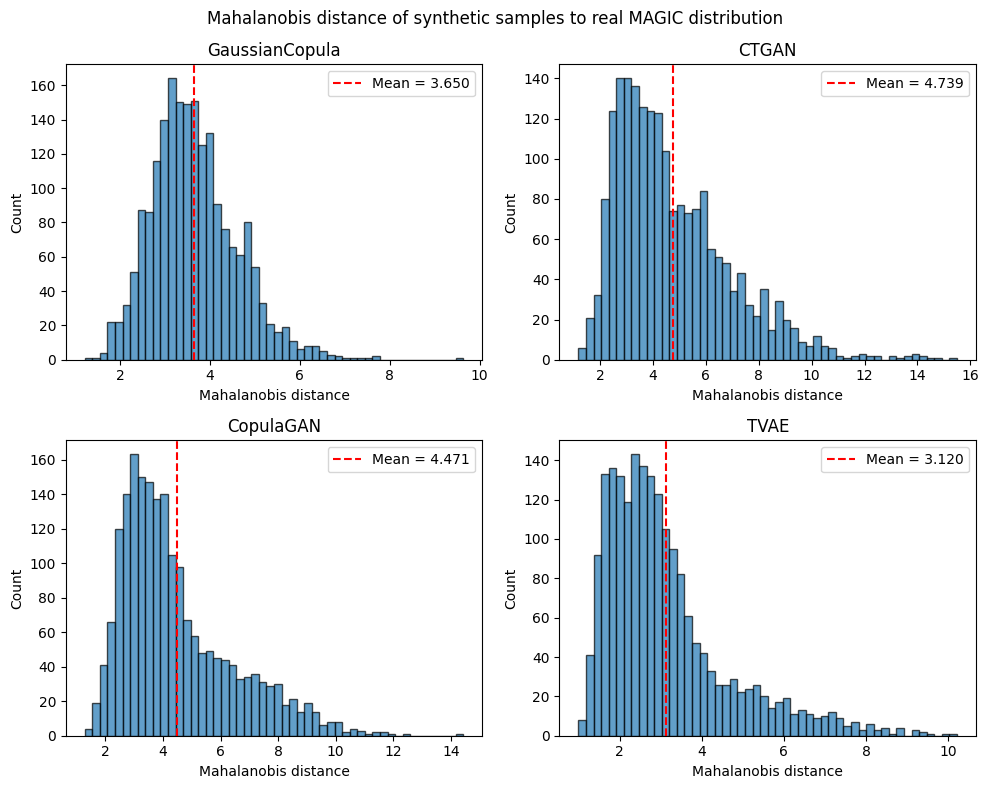

In [35]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mahalanobis distance of synthetic samples to real MAGIC distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
os.makedirs(os.path.join(ROOT, "figures"), exist_ok=True)
plt.savefig(
    os.path.join(ROOT, "figures", "mahalanobis_magic_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [36]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = magic_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = metric_subsample_df(magic_data)[num_cols].to_numpy(dtype=float)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)


Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
TVAE,2.000846,1.494012,1.516726,17.225195
GaussianCopula,2.490962,2.273775,1.134256,12.606340
CopulaGAN,3.055436,2.571091,1.806836,14.056917
CTGAN,3.383397,2.863819,2.080613,16.566524


In [37]:
# Greedy mapping 
import numpy as np
import pandas as pd

def greedy_one_to_one_matching(D):
    n_rows, n_cols = D.shape
    n = min(n_rows, n_cols)

    used_rows = set()
    used_cols = set()
    pairs = []

    for _ in range(n):
        best_val = np.inf
        best_i, best_j = -1, -1

        for i in range(n_rows):
            if i in used_rows:
                continue
            for j in range(n_cols):
                if j in used_cols:
                    continue
                if D[i, j] < best_val:
                    best_val = D[i, j]
                    best_i, best_j = i, j

        if best_i < 0:
            break

        used_rows.add(best_i)
        used_cols.add(best_j)
        pairs.append((best_i, best_j, best_val))

    distances = np.array([p[2] for p in pairs], dtype=float)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = magic_data.select_dtypes(include=[np.number]).columns.tolist()
real_matrix = magic_data[num_cols].to_numpy(dtype=float)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=float)

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    total_g, mean_g, _ = greedy_one_to_one_matching(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Greedy total": total_g,
        "Hungarian total": h_total,
        "Greedy mean": mean_g,
        "Hungarian mean": h_mean,
        "Total diff (Greedy - Hungarian)": total_g - h_total,
        "Mean diff (Greedy - Hungarian)": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (Mahalanobis distance):")
display(greedy_summary)

print("\nComparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)


Greedy one-to-one matching (Mahalanobis distance):


,total_distance,mean_distance
Model,,
GaussianCopula,3897.952058,1.948976
CTGAN,4867.680411,2.433840
CopulaGAN,4401.690481,2.200845
TVAE,2516.739136,1.258370



Comparison: Greedy vs Hungarian (lower is better; Greedy should be >= Hungarian):


,Greedy total,Hungarian total,Greedy mean,Hungarian mean,Total diff (Greedy - Hungarian),Mean diff (Greedy - Hungarian)
Model,,,,,,
GaussianCopula,3897.952058,4981.923317,1.948976,2.490962,-1083.971259,-0.541986
CTGAN,4867.680411,6766.794285,2.433840,3.383397,-1899.113874,-0.949557
CopulaGAN,4401.690481,6110.871709,2.200845,3.055436,-1709.181228,-0.854591
TVAE,2516.739136,4001.692895,1.258370,2.000846,-1484.953759,-0.742477


In [38]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=float)
    S = synth_df[feature_cols].to_numpy(dtype=float)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=float), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = metric_subsample_df(magic_data)

feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "class"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=float)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 10
GaussianCopula: avg matched Mahalanobis distance = 2.2907
CTGAN: avg matched Mahalanobis distance = 3.2592
CopulaGAN: avg matched Mahalanobis distance = 2.8989
TVAE: avg matched Mahalanobis distance = 1.8710


In [39]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in magic_data.select_dtypes(include=[np.number]).columns if c != "class"]
real_df = metric_subsample_df(magic_data)
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
hungarian_results = {}

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    hungarian_results[model_name] = {"row_ind": row_ind, "col_ind": col_ind, "dists": dists}

    order = np.argsort(dists)
    top_k = min(20, len(order))

    print(f"\n{model_name} - Top {top_k} Hungarian matchings (lowest Mahalanobis distance):")
    for rank, k in enumerate(order[:top_k], 1):
        print(f"{rank:02d}. R{row_ind[k] + 1} -> S{col_ind[k] + 1}   distance = {dists[k]:.4f}")



CTGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R904 -> S1169   distance = 0.4484
02. R1426 -> S462   distance = 0.4905
03. R62 -> S1583   distance = 0.5486
04. R1401 -> S171   distance = 0.5587
05. R909 -> S795   distance = 0.5756
06. R212 -> S1242   distance = 0.5870
07. R1190 -> S1283   distance = 0.5931
08. R1812 -> S586   distance = 0.6077
09. R1704 -> S1229   distance = 0.6122
10. R1684 -> S182   distance = 0.6819
11. R1312 -> S1762   distance = 0.6829
12. R1855 -> S1901   distance = 0.7086
13. R806 -> S645   distance = 0.7093
14. R858 -> S834   distance = 0.7106
15. R602 -> S1919   distance = 0.7195
16. R1245 -> S967   distance = 0.7335
17. R482 -> S1691   distance = 0.7514
18. R526 -> S1909   distance = 0.7589
19. R1615 -> S298   distance = 0.7744
20. R1766 -> S925   distance = 0.7802

CopulaGAN - Top 20 Hungarian matchings (lowest Mahalanobis distance):
01. R1414 -> S194   distance = 0.4286
02. R1815 -> S168   distance = 0.4758
03. R1633 -> S591   distan

In [40]:

if 'metric_subsample_df' not in globals():
    METRIC_SAMPLE_SIZE = 2000
    METRIC_RANDOM_STATE = 42
    def metric_subsample_df(df, n_max=METRIC_SAMPLE_SIZE, random_state=METRIC_RANDOM_STATE):
        if len(df) <= n_max:
            return df.reset_index(drop=True)
        return df.sample(n=n_max, random_state=random_state).reset_index(drop=True)

import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = [c for c in magic_data.select_dtypes(include=[np.number]).columns if c != "class"]
real_df = metric_subsample_df(magic_data)
X_real = real_df[feature_cols].to_numpy(dtype=float)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=float)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")


CTGAN - Hungarian mappings for R1 to R20:
R1 -> S494   distance = 1.6162
R2 -> S1516   distance = 6.4769
R3 -> S1077   distance = 1.5140
R4 -> S62   distance = 1.7952
R5 -> S1272   distance = 4.3689
R6 -> S1022   distance = 1.3809
R7 -> S907   distance = 1.3525
R8 -> S624   distance = 2.9147
R9 -> S1571   distance = 1.6599
R10 -> S21   distance = 2.1113
R11 -> S1181   distance = 2.3480
R12 -> S1319   distance = 9.2175
R13 -> S201   distance = 2.2253
R14 -> S1268   distance = 3.2164
R15 -> S1785   distance = 2.2520
R16 -> S1790   distance = 1.2122
R17 -> S441   distance = 4.7260
R18 -> S1446   distance = 4.3414
R19 -> S1405   distance = 2.9452
R20 -> S557   distance = 3.7882

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S1265   distance = 2.9448
R2 -> S1004   distance = 5.4978
R3 -> S201   distance = 1.4530
R4 -> S1142   distance = 1.5535
R5 -> S190   distance = 4.9742
R6 -> S17   distance = 5.1695
R7 -> S655   distance = 1.3088
R8 -> S1503   distance = 3.4415
R9 -> S337   dista

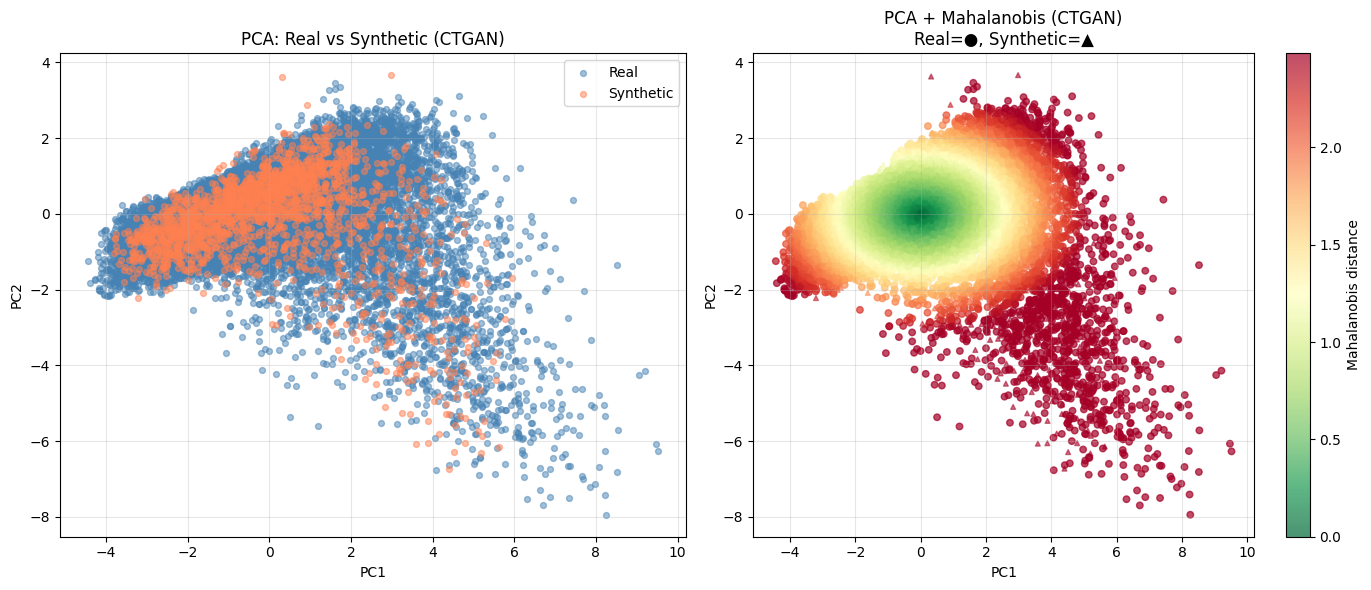

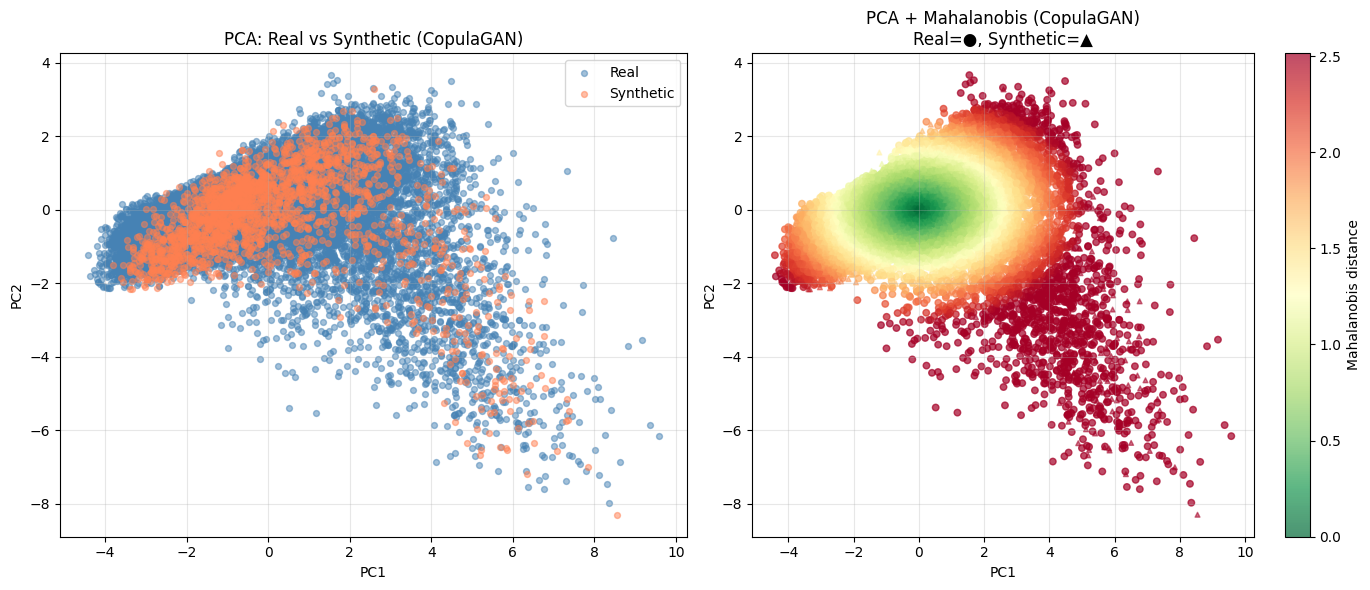

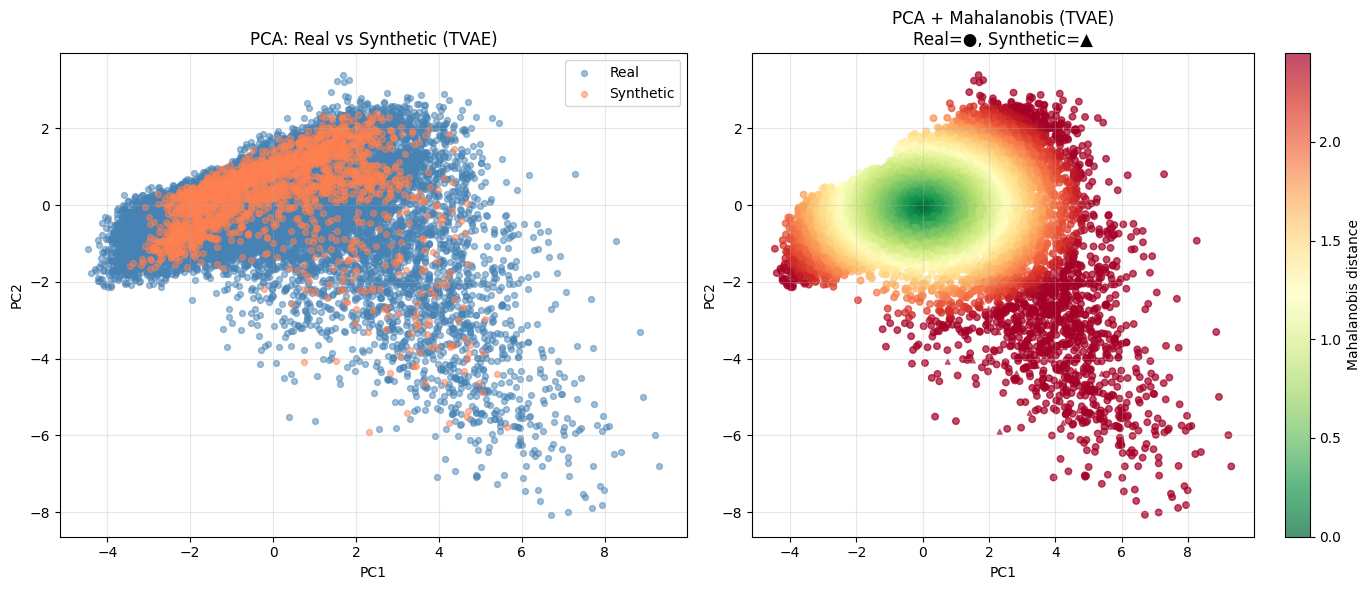

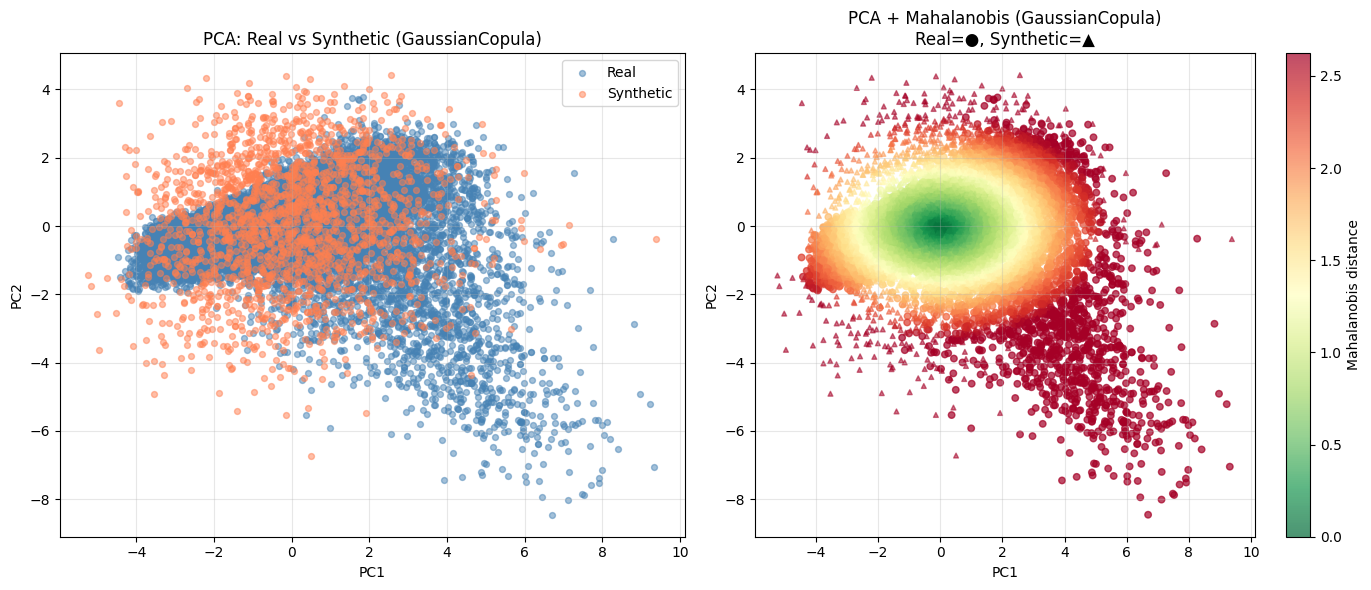

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
2,TVAE,1.172018,1.110660,-0.061359
0,CTGAN,1.170901,1.157158,-0.013743
1,CopulaGAN,1.169620,1.241461,0.071840
3,GaussianCopula,1.161960,1.551412,0.389452


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = magic_data.copy()
feature_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "class"]

X_r = real_df[feature_cols].to_numpy(dtype=float)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=float)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = inv(cov_z + 10 * reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)


In [42]:
# print results on excel sheets 

import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_MAGIC.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            matched_df.to_excel(writer, sheet_name=model_name[:31], index=False)

            summary_rows.append({
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="Summary", index=False)

    print(f"Excel file created: {filename}")

# ---- Run ----
real_df = magic_data.copy()
num_cols = [c for c in real_df.select_dtypes(include=[np.number]).columns if c != "class"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_MAGIC.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_MAGIC.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)


In [43]:
# MIA with ML regression model 

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample(model, X, y, eps=1e-15):
    proba = model.predict_proba(X)
    n = len(y)
    y_idx = y.astype(int).clip(0, proba.shape[1] - 1)
    p_true = proba[np.arange(n), y_idx] + eps
    return -np.log(p_true)

def privacy_metrics_mia(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    model.fit(X_train_s, y_train)

    loss_train = model_loss_per_sample(model, X_train_s, y_train)
    loss_test = model_loss_per_sample(model, X_test_s, y_test)

    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx_fpr_001 = np.searchsorted(fpr, 0.01, side="right") - 1
    idx_fpr_001 = max(0, idx_fpr_001)
    tpr_at_fpr_001 = tpr[idx_fpr_001] if idx_fpr_001 < len(tpr) else float("nan")

    return {"AUC": auc, "Advantage": advantage, "TPR_at_FPR_001": tpr_at_fpr_001}

target_col = "class"
feature_cols = [c for c in magic_data.select_dtypes(include=[np.number]).columns if c != target_col]

real_df = magic_data.copy()
synth_df = synthetic_data["GaussianCopula"][real_df.columns].copy()

X_train = real_df[feature_cols].to_numpy(dtype=float)
y_train = real_df[target_col].to_numpy(dtype=int)

X_test = synth_df[feature_cols].to_numpy(dtype=float)
y_test = synth_df[target_col].to_numpy(dtype=int)

model = LogisticRegression(max_iter=1000, random_state=42)
metrics = privacy_metrics_mia(model, X_train, y_train, X_test, y_test)
print(metrics)


{'AUC': 0.5631045741324922, 'Advantage': np.float64(0.15160778128286023), 'TPR_at_FPR_001': np.float64(0.03249211356466877)}


In [44]:
# MIA with Mahalanobis 

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = [c for c in magic_data.select_dtypes(include=[np.number]).columns if c != "class"]
X_train = magic_data[feature_cols].to_numpy(dtype=float)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=float)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)

MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTGAN,0.778286,0.435410,0.059621,2.818366,4.580937
1,CopulaGAN,0.759973,0.405778,0.078391,2.818366,4.283004
2,GaussianCopula,0.727197,0.391552,0.104784,2.818366,3.451592
3,TVAE,0.496098,0.067659,0.005468,2.818366,2.925421
